# Aged Mouse Analysis
Dataset: Takasugi et al., Nature 2024 

Last Updated: 06-18-2026

# Directories, Dependencies, Helper Functions, & Data Pre-processing

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg


print("packages have been successfully read in!")

packages have been successfully read in!


In [2]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR     = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Takasugi_2024/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
MQ_DIR          = PROJ_DIR + 'mq_output/Takasugi_2024/'
PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + '/Supplementary_Tables/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## Define dataset/TMT set folders 
#S1 AORTA
aorta_proj_dir      = OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_mq            = MQ_DIR + 'Aorta/'

#S2 BRAIN 
brain_proj_dir      = OUTDIR + 'Brain/'
brain_aa_subs_dir   = INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_mq            = MQ_DIR + 'Brain/'

#S3 HEART
heart_proj_dir      = OUTDIR + 'Heart/'
heart_aa_subs_dir   = INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_mq            = MQ_DIR + 'Heart/'

#S4 KIDNEY
kidney_proj_dir      = OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_mq            = MQ_DIR + 'Kidney/'

#S5 LIVER
liver_proj_dir      = OUTDIR + 'Liver/'
liver_aa_subs_dir   = INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_mq            = MQ_DIR + 'Liver/'

#S6 LUNG
lung_proj_dir      = OUTDIR + 'Lung/'
lung_aa_subs_dir   = INDIR + 'Lung/'
lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
lung_mq            = MQ_DIR + 'Lung/'

#S7 MUSCLE
muscle_proj_dir      = OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_mq            = MQ_DIR + 'Muscle/'

#S8 SKIN
skin_proj_dir      = OUTDIR + 'Skin/'
skin_aa_subs_dir   = INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_mq            = MQ_DIR + 'Skin/'

#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map]
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir]
mq_dir_list = [aorta_mq, brain_mq, heart_mq, kidney_mq, liver_mq, lung_mq, muscle_mq, skin_mq]


print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [3]:
# Read in data generated from dependencies code
# if dependencies have not been generated, go back and generate in Analysis_Dependencies_ipynb

pos_prob_df = pd.read_csv(DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
print(pos_prob_df)
frag_dict = pickle.load(open(DEPDIR+'Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
print(frag_dict)

SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
#SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
# print(SAAP_quant_df)
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

                              SAAP                             BP       AAS  \
0                        SALSGLLHR                      AALSGLLHR    A to S   
1                        SALSGLLHR                      AALSGLLHR    A to S   
2                         PATVSLPR                       VATVSLPR    V to P   
3                         PFLENVIR                       VFLENVIR    V to P   
4                        LPGGTTPGK                      LVGGTTPGK    V to P   
..                             ...                            ...       ...   
122               STLSVITSGVQWIQDR               STLSVIPSGVQWIQDR    P to T   
123  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ    P to T   
124        DNLTLWNSDTQGDEAEAGEGGEN        DNLTLWTSDTQGDEAEAGEGGEN    T to N   
125            DSTYSMSSLLTLTKDEYER            DSTYSMSSTLTLTKDEYER  T to I/L   
126            LYTWGVVEVENPEHNDFLK            LYPWGVVEVENPEHNDFLK    P to T   

     AAS index  Positional probability  charge TMT 

In [4]:
# Save as Supplemental_Data_1.SAAP_precursor_reporter_quant_aging.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_1.SAAP_precursor_reporter_quant_aging.xlsx',sheet_name='Users',index=True)

## Data Pre-processing

### a. Assess data completeness

In [5]:
# Assess data completeness of SAAPs in SAAP_quant_df 
print(f'{len(SAAP_quant_df):,} total SAAP observations in original dataset')
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% original dataset completeness')

# Option to replace read-in SAAP_quant_df with SAAP_quant_df that has 100% data completeness
# SAAP_quant_df = SAAP_quant_complete_df 

19,520 total SAAP observations in original dataset
17,877 fully complete SAAP observations retained
91.58% original dataset completeness


  Dataset  Completeness
0   Aorta     96.965241
1   Brain     97.477273
2   Heart     98.264687
3  Kidney     96.695752
4   Liver     96.551724
5    Lung     97.869318
6  Muscle     98.279672
7    Skin     98.737374


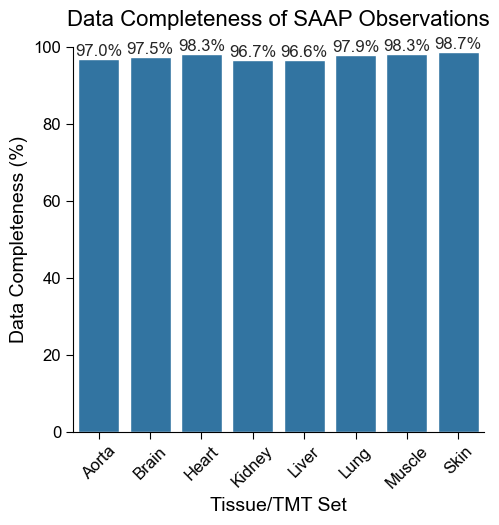

In [6]:
# Plot data completeness per tissue/TMT set 
comp_cols=['Positional_probability','SAAP_PEP','BP_PEP','MTP_PrecInt','BP_PrecInt','Prec_RAAS','MTP_ReportInt','BP_ReportInt','Reporter_RAAS','BP_ReportInt_Norm','MTP_ReportInt_Norm']

comp_df = SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df = comp_df[comp_df['Dataset']==ds]
    total_val = len(ds_df)*len(comp_cols)
    nonmissing_val = sum(ds_df[c].notna().sum() for c in comp_cols)
    completeness = 100*(nonmissing_val/total_val)
    plot_rows.append({'Dataset': ds, 'Completeness': completeness})

plot_df = pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
print(plot_df)

fig,ax = plt.subplots(figsize=(5.3,5))
sns.set_style('ticks')
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color='#1f78b4',ax=ax)
ax.tick_params('both',labelsize=12,length=5)
ax.tick_params(axis='x',rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('Data Completeness (%)',fontsize=14)
plt.ylim(0,100) 
plt.title('Data Completeness of SAAP Observations',fontsize=16,pad=15)
sns.despine()

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',label_type='edge',fontsize=12)

plt.savefig(PLOT_DIR + 'SAAP_data_completeness.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR + 'SAAP_data_completeness.png',dpi=600,bbox_inches='tight')

### b. Remove immunoglobulins and trypsin mapping SAAPs 

In [7]:
"""
Assign each SAAP a source protein/gene from evidence.txt & drop Ig/trypsin/unresolved

1. Each SAAP (MTP_seq) is a substituted peptide that exists only in the synthetic search
space, so its parent protein is read off the BASE peptide (BP_seq) — the reference
sequence string-searched in that SAAP's OWN tissue (Dataset) MaxQuant evidence.txt.
2. Gene symbols and protein descriptions come from proteinGroups.txt FASTA headers (GN=).
3. SAAPs are dropped if their base peptide maps to an immunoglobulin chain, to trypsin,
or to no NAMED protein (no gene and no description), before any downstream QC.

NOTE: resolution is keyed by (Dataset, BP_seq) so a base peptide observed in multiple
tissues is matched only against its own tissue's evidence.txt.
"""

# keep only the lead (first) accession per base peptide, dropping the rest of the group
LEAD_ACCESSION_ONLY = True

def canon(acc):
    """Canonical accession: drop CON__ prefix, isoform (-2) and contaminant version (v2) suffixes."""
    acc = acc.replace('CON__', '').split('-')[0]
    return re.sub(r'v\d+$', '', acc)  # P35908v2 -> P35908 (MaxQuant contaminant versioning)

# accession -> (gene, description) parsed from every tissue's proteinGroups.txt FASTA headers
hdr_re = re.compile(r'(?:sp|tr)\|([^|]+)\|\S+\s+(.+?)\s+OS=')
gn_re  = re.compile(r'GN=(\S+)')
acc_gene, acc_desc = {}, {}
for mq_dir in mq_dir_list:
    headers = pd.read_csv(mq_dir+'proteinGroups.txt', sep='\t', usecols=['Fasta headers'])['Fasta headers']
    for header in headers.dropna():
        for entry in header.split(';'):
            m = hdr_re.search(entry)
            if not m:
                continue
            acc = canon(m.group(1))  # key on canonical accession so isoform lookups resolve
            acc_desc.setdefault(acc, m.group(2).strip())
            g = gn_re.search(entry)
            if g:
                acc_gene.setdefault(acc, g.group(1))
print(f'{len(acc_desc):,} reference proteins parsed from FASTA headers')

# (dataset, peptide sequence) -> MaxQuant 'Proteins' string, indexed PER TISSUE so a base
# peptide shared across tissues resolves against its own tissue's evidence.txt.
seq_to_proteins = {}
for dataset, mq_dir in zip(datasets, mq_dir_list):
    ev = pd.read_csv(mq_dir+'evidence.txt', sep='\t', usecols=['Sequence', 'Proteins'])
    for seq, prot in zip(ev['Sequence'], ev['Proteins'].astype(str)):
        if prot != 'nan':
            seq_to_proteins.setdefault((dataset, seq), prot)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(mq_dir_list)} evidence.txt files')

def proteins_to_accessions(protein_str):
    """Real UniProt accessions in a MaxQuant 'Proteins' string (drops synthetic MTP| entries).
    With LEAD_ACCESSION_ONLY, returns only the leading (first) accession in the group."""
    accs = []
    for tok in str(protein_str).split(';'):
        tok = tok.replace('CON__', '')
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append(canon(m.group(1)))  # canonicalize to match FASTA-header keys
    accs = list(dict.fromkeys(accs))  # unique, order-preserving
    return accs[:1] if LEAD_ACCESSION_ONLY else accs

# resolve each SAAP's base peptide to accessions within its own tissue
row_accs = [proteins_to_accessions(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'], SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].head(10).to_string())

# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))

11,818 reference proteins parsed from FASTA headers
342,446 unique (tissue, peptide) pairs indexed across 8 evidence.txt files
              MTP_seq     BP_seq Dataset Source_gene                                    Source_protein
Row Number                                                                                            
0           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
1           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
2           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
3           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
4           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
5           SALSGLLHR  AALSGLLHR   Aorta       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
6           SALSGLLHR  AALSGLLHR   Aorta       Ha

In [8]:
# """
# Assign each SAAP a source protein/gene from evidence.txt & drop Ig/trypsin

# 1. Each SAAP (MTP_seq) is a substituted peptide that exists only in the synthetic search
# space, so its parent protein is read off the BASE peptide (BP_seq) — the reference
# sequence string-searched across every dataset's MaxQuant evidence.txt. 
# 2. Gene symbols and protein descriptions come from the proteinGroups.txt FASTA headers 
# (GN= field). 
# 3. SAAPs whose base peptide maps to an immunoglobulin chain or to trypsin are dropped as
# contaminants before any downstream QC.
# """

# # accession -> (gene, description) parsed from every dataset's FASTA headers
# hdr_re = re.compile(r'(?:sp|tr)\|([^|]+)\|\S+\s+(.+?)\s+OS=')
# gn_re  = re.compile(r'GN=(\S+)')
# acc_gene, acc_desc = {}, {}
# for mq_dir in mq_dir_list:
#     headers = pd.read_csv(mq_dir+'proteinGroups.txt', sep='\t', usecols=['Fasta headers'])['Fasta headers']
#     for header in headers.dropna():
#         for entry in header.split(';'):
#             m = hdr_re.search(entry)
#             if not m:
#                 continue
#             acc_desc.setdefault(m.group(1), m.group(2).strip())
#             g = gn_re.search(entry)
#             if g:
#                 acc_gene.setdefault(m.group(1), g.group(1))
# print(f'{len(acc_desc):,} reference proteins parsed from FASTA headers')

# # peptide sequence -> MaxQuant 'Proteins' string, string-searched across every evidence.txt
# seq_to_proteins = {}
# for mq_dir in mq_dir_list:
#     ev = pd.read_csv(mq_dir+'evidence.txt', sep='\t', usecols=['Sequence', 'Proteins'])
#     for seq, prot in zip(ev['Sequence'], ev['Proteins'].astype(str)):
#         if prot != 'nan':
#             seq_to_proteins.setdefault(seq, prot)
# print(f'{len(seq_to_proteins):,} unique peptide sequences indexed across {len(mq_dir_list)} evidence.txt files')

# def proteins_to_accessions(protein_str):
#     """Real UniProt accessions in a MaxQuant 'Proteins' string (drops synthetic MTP| entries)."""
#     accs = []
#     for tok in str(protein_str).split(';'):
#         tok = tok.replace('CON__', '')
#         if tok.startswith('MTP'):
#             continue
#         m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
#         if m:
#             accs.append(m.group(1).split('-')[0])
#     return list(dict.fromkeys(accs))  # unique, order-preserving

# # resolve each SAAP's base peptide to accessions / genes / descriptions
# row_accs = [proteins_to_accessions(seq_to_proteins.get(bp, '')) for bp in SAAP_quant_df['BP_seq']]
# row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
# row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

# def first_nonempty(values):
#     return next((v for v in values if v), '')

# # append observations to SAAP_quant_df 
# SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
# SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
# SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
# print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Source_gene', 'Source_protein']].head(10).to_string())

# # flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# # Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# # members, IgLON, anti-trypsin, or chymotrypsin.
# ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
# ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
# tryp_desc_re = re.compile(r'(?i)\btrypsin')
# tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
# TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

# def is_immunoglobulin(accs):
#     return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
#                or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

# def is_trypsin(accs):
#     return any(a in TRYPSIN_ACCESSIONS or
#                (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
#                for a in accs)

# SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
# SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
# print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
# print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
# print('immunoglobulin source proteins removed:',
#       sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
# print('trypsin source proteins removed:',
#       sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))

5
1
400
          Category  Count
0  Immunoglobulins      5
1         Trypsins      1
2            SAAPs    400


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3776715020.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)


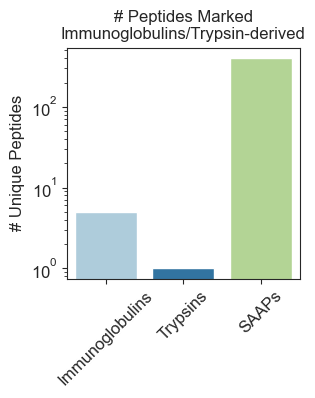

In [9]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(3,3))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [10]:
# drop SAAPs that map to no NAMED protein (blank gene AND blank description), then drop the
# immunoglobulin and trypsin contaminants. This removes contaminant-only / unnamed hits.
n0 = len(SAAP_quant_df)
# unnamed = (SAAP_quant_df['Source_gene'] == '') & (SAAP_quant_df['Source_protein'] == '')
unnamed = (SAAP_quant_df['Source_gene'] == '')
print(f"\n{unnamed.sum():,} SAAP observations map to no named protein — dropped")
drop_mask = unnamed | (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)
print(f'{n0:,} -> {len(SAAP_quant_df):,} SAAP observations retained '
      f'({drop_mask.sum():,} dropped: unnamed + immunoglobulin + trypsin)')


1,168 SAAP observations map to no named protein — dropped
19,520 -> 18,272 SAAP observations retained (1,248 dropped: unnamed + immunoglobulin + trypsin)


In [11]:
# # drop the contaminant SAAPs and rebuild the per-dataset views
# n_before = len(SAAP_quant_df)
# SAAP_quant_df = SAAP_quant_df.loc[(SAAP_quant_df['immunoglobulin'] == 'NO') &
#                                   (SAAP_quant_df['trypsin'] == 'NO')].copy()
# print(f'\n{n_before:,} -> {len(SAAP_quant_df):,} SAAP observations after removing immunoglobulin/trypsin matches')
# SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset'] == ds] for ds in datasets]

# 1. SAAP Detection & QC

## 1a Dataset Metrics

In [12]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 600x500 with 0 Axes>

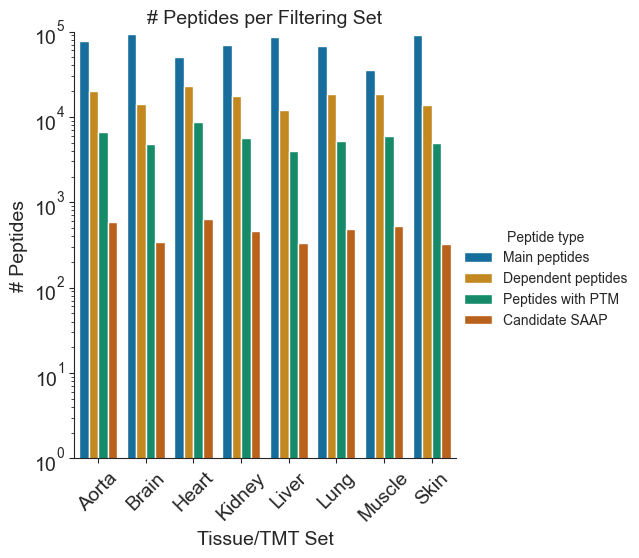

In [13]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(6,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1)

ax.set(yscale='log', ylim=(1, 1e5))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

### Percentage of candidate SAAPs validated through database search

In [14]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

Aorta
Brain
Heart
Kidney
Liver
Lung
Muscle
Skin


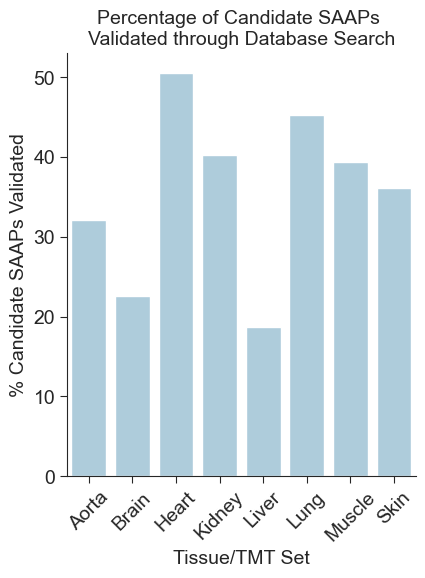

In [15]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='Paired')
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14)
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

## 1b Validation Metrics

### Positional probability filtering

7728
18272


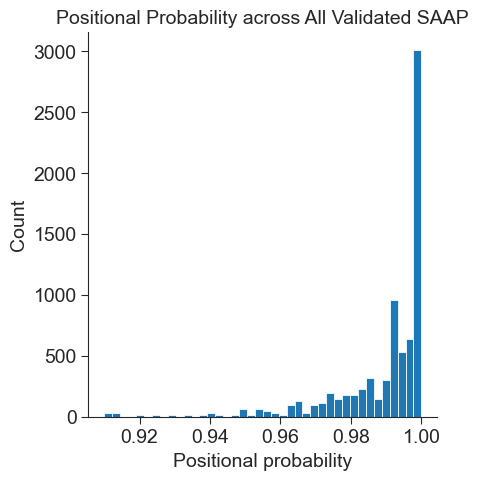

In [16]:
# Filter SAAP_quant_df by SAAP with positional probability => 0.9
SAAP_quant_df_posprobfilt = SAAP_quant_df[SAAP_quant_df['Positional_probability'] >= 0.9]
print(len(SAAP_quant_df_posprobfilt))
print(len(SAAP_quant_df))
SAAP_quant_df = SAAP_quant_df_posprobfilt

# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

7728
7728


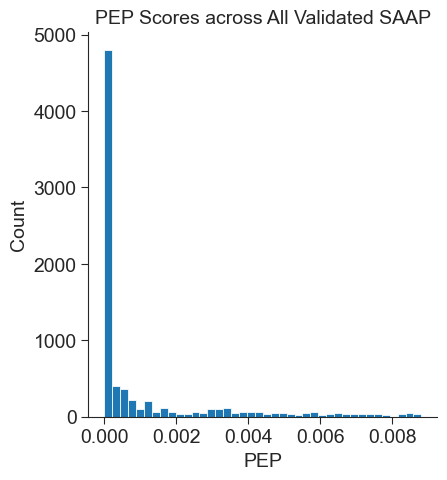

In [17]:
# Filter out SAAP with PEP <= 0.01 
SAAP_quant_df_PEPfilt = SAAP_quant_df[SAAP_quant_df['SAAP_PEP'] <= 0.1]
print(len(SAAP_quant_df_PEPfilt))
print(len(SAAP_quant_df))
SAAP_quant_df = SAAP_quant_df_PEPfilt

# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

In [18]:
# Save as Supplemental_Data_2.SAAP_precursor_reporter_quant_aging_highConfidence.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_2.SAAP_precursor_reporter_quant_aging_HighConfidence.xlsx',sheet_name='Users',index=True)

### Fragment ion support at substitution site

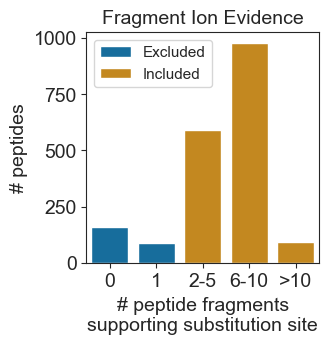

In [19]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = pd.read_excel(DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind')
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

### PEP scores and q values

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/1426888465.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/1426888465.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/1426888465.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/1426888465.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


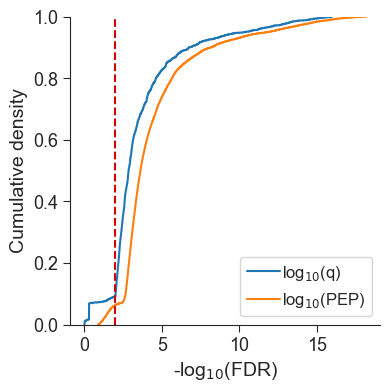

In [20]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.png',dpi=600, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/2872710814.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/2872710814.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/2872710814.py:58: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = hi

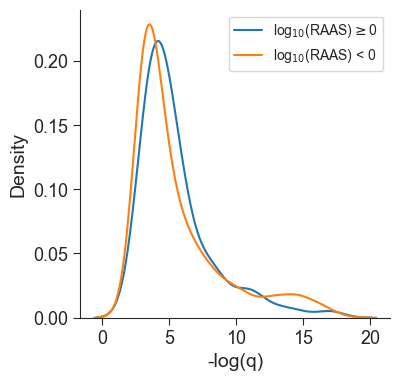

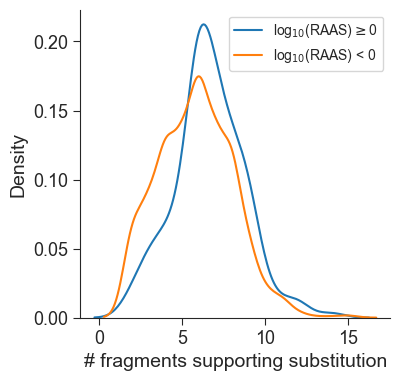

In [21]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log(q)', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.png', dpi=600, bbox_inches='tight')


# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.png',dpi=600, bbox_inches='tight')

### Mass errors for SAAPs and main peptides

In [22]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

Aorta S1 rows: 896
     MTP_seq  Reporter_RAAS
0  SALSGLLHR      -1.534776
1  SALSGLLHR      -1.607140
2  SALSGLLHR      -1.623710
3  SALSGLLHR      -1.616215
4  SALSGLLHR      -1.649804
High SAAP: ['LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'DLYANDVLSGGTTMYPGIADR', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'LKAEFQEEAK', 'LKAEFQEEAK', 'LKAEFQEEAK', 'LKAEFQEEAK', 'LKAEFQEEAK', 'LKAEFQEEA

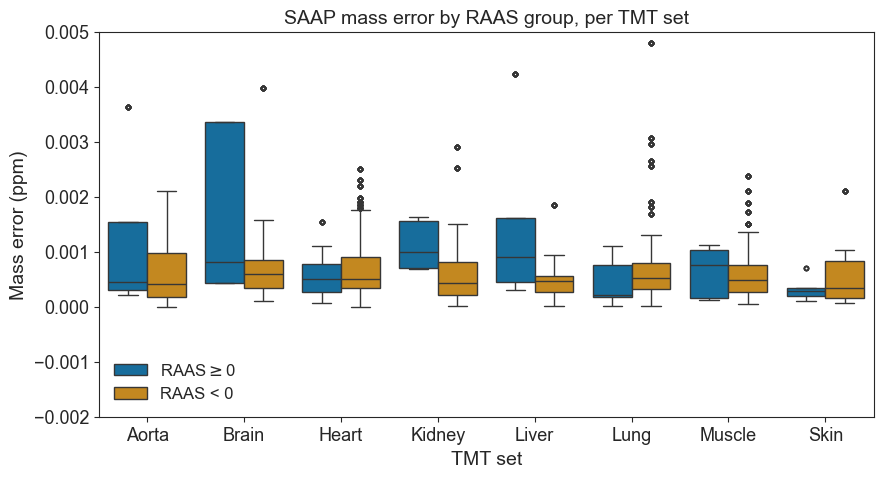

In [23]:
# mass error analysis
SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{ds} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[ds]['High RAAS mass error']  = mass_err_dict[ds]['High RAAS mass error'] + high_errs
            mass_err_dict[ds]['Low RAAS mass error']  = mass_err_dict[ds]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

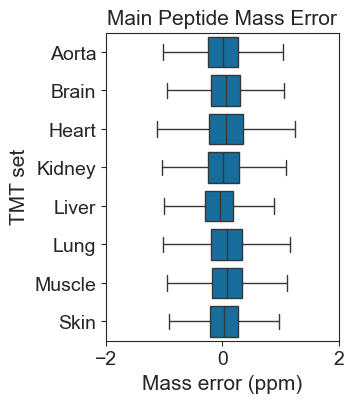

In [24]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[ds]['Main peptide mass error'] = mass_err_dict[ds]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

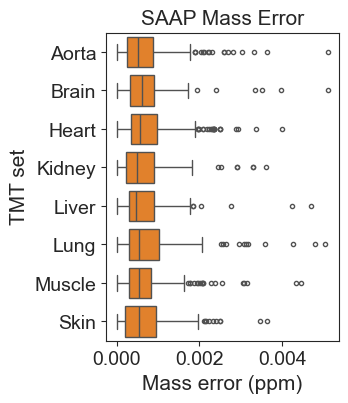

In [25]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[ds]['SAAP mass error'] = mass_err_dict[ds]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

### N SAAPs post-filtering/validation

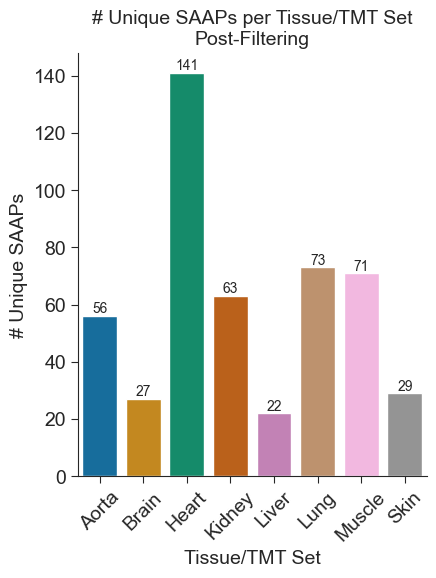

In [26]:
# N SAAPs per dataset post-filtering
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.png',dpi=600,bbox_inches='tight')

# 2. RAAS

## 2a Global Metrics

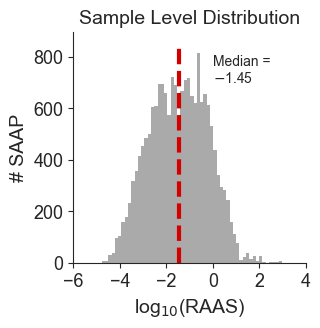

In [27]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

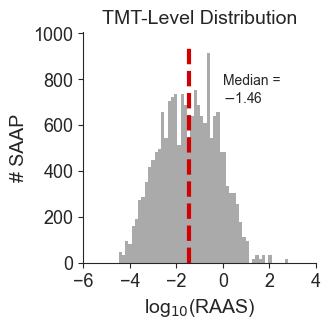

In [28]:
# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4])
ax.set_title(r'TMT-Level Distribution',fontsize=14)
sns.despine()

plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.png', dpi=600, bbox_inches='tight')

## 2b Precursor and Reporter RAAS Agreeability

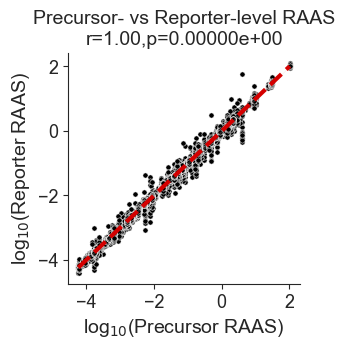

In [29]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color="#000000",edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

## 2c Tissue-level RAAS Distributions

In [30]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=10, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/2702066803.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


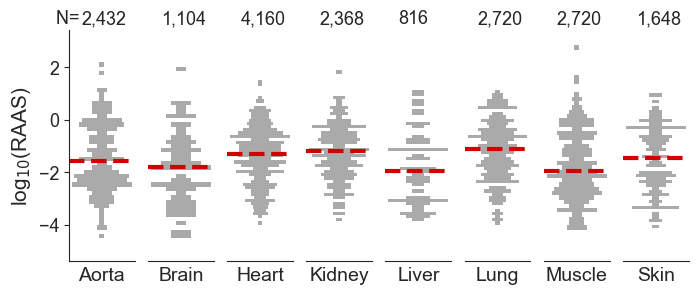

In [31]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Prec_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians)) # sort by median instead
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.png',dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3349579470.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


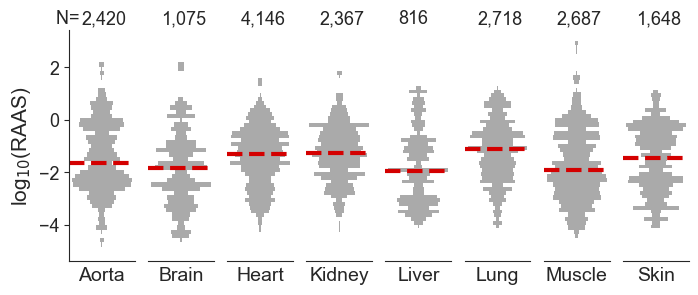

In [32]:
# sample/reporter ion level RAAS distributions for each dataset, code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/487779949.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


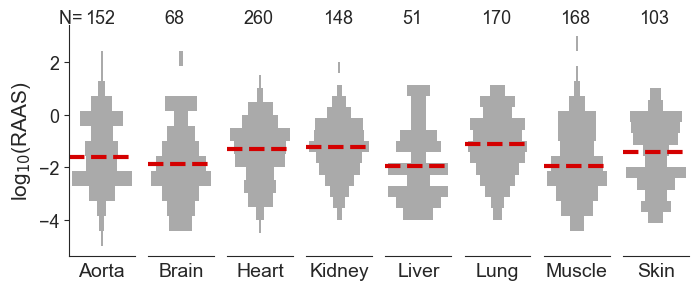

In [33]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

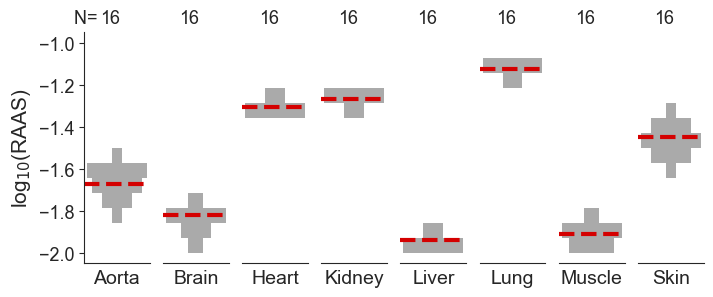

In [34]:
# Sample median RAAS distributions
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)
        
medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in sample_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

SAAPs in >= 6 tissues: 5


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/2150870746.py:28: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


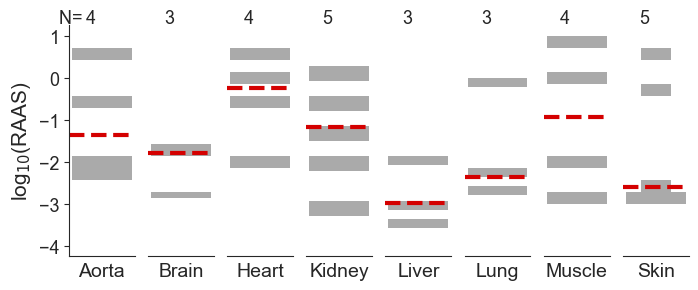

In [73]:
# Median RAAS distributions for SAAPs shared across all tissues, per dataset
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# SAAPs (MTP_seq) present in every dataset/tissue
saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
from collections import Counter

MIN_TISSUES = 6  # set to e.g. 2 for "≥2 tissues", or len(datasets) for strict

saap_set_list = [set(SAAP_quant_df_list[i]['MTP_seq'].values) for i in range(len(datasets))]
counts = Counter()
for s in saap_set_list:
    counts.update(s)
shared_saap = {s for s,c in counts.items() if c >= MIN_TISSUES}
print('SAAPs in >= {} tissues: {}'.format(MIN_TISSUES, len(shared_saap)))

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in shared_saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_sharedSAAP.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3245370680.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


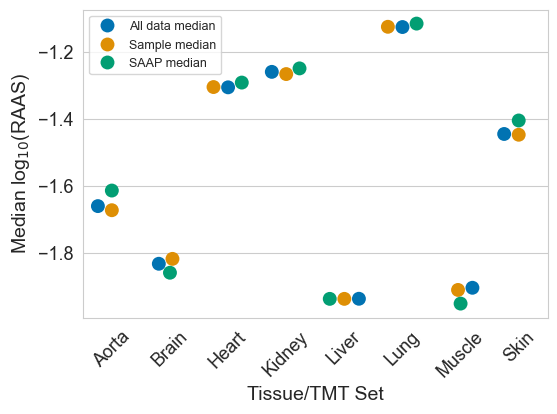

In [62]:
# Medians for all data, sample, and SAAP-level RAAS 
all_medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
all_medians.append(np.nanmedian(SAAP_quant_df_list[-1]['Reporter_RAAS'].values))

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)

sample_medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets))]
saap_medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets))]

plot_rows = []
plot_cols = ['Dataset', 'Median RAAS', 'Median type']
for m, median in enumerate(all_medians):
    plot_rows.append([datasets[m], median, 'All data median'])
for m, median in enumerate(sample_medians):
    plot_rows.append([datasets[m], median, 'Sample median'])
for m, median in enumerate(saap_medians):
    plot_rows.append([datasets[m], median, 'SAAP median'])
    
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)    

fig,ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plot_df, x='Dataset', y='Median RAAS', hue='Median type', s=10,
              palette='colorblind',order=tissue_order)
plt.legend(loc='upper left',title='', fontsize=9)
ax.tick_params('both', labelsize=13)
plt.xticks(rotation=45)
plt.ylabel('Median log$_{10}$(RAAS)', fontsize=14)
plt.xlabel('Tissue/TMT Set',fontsize=14)

plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.png', dpi=600, bbox_inches='tight')

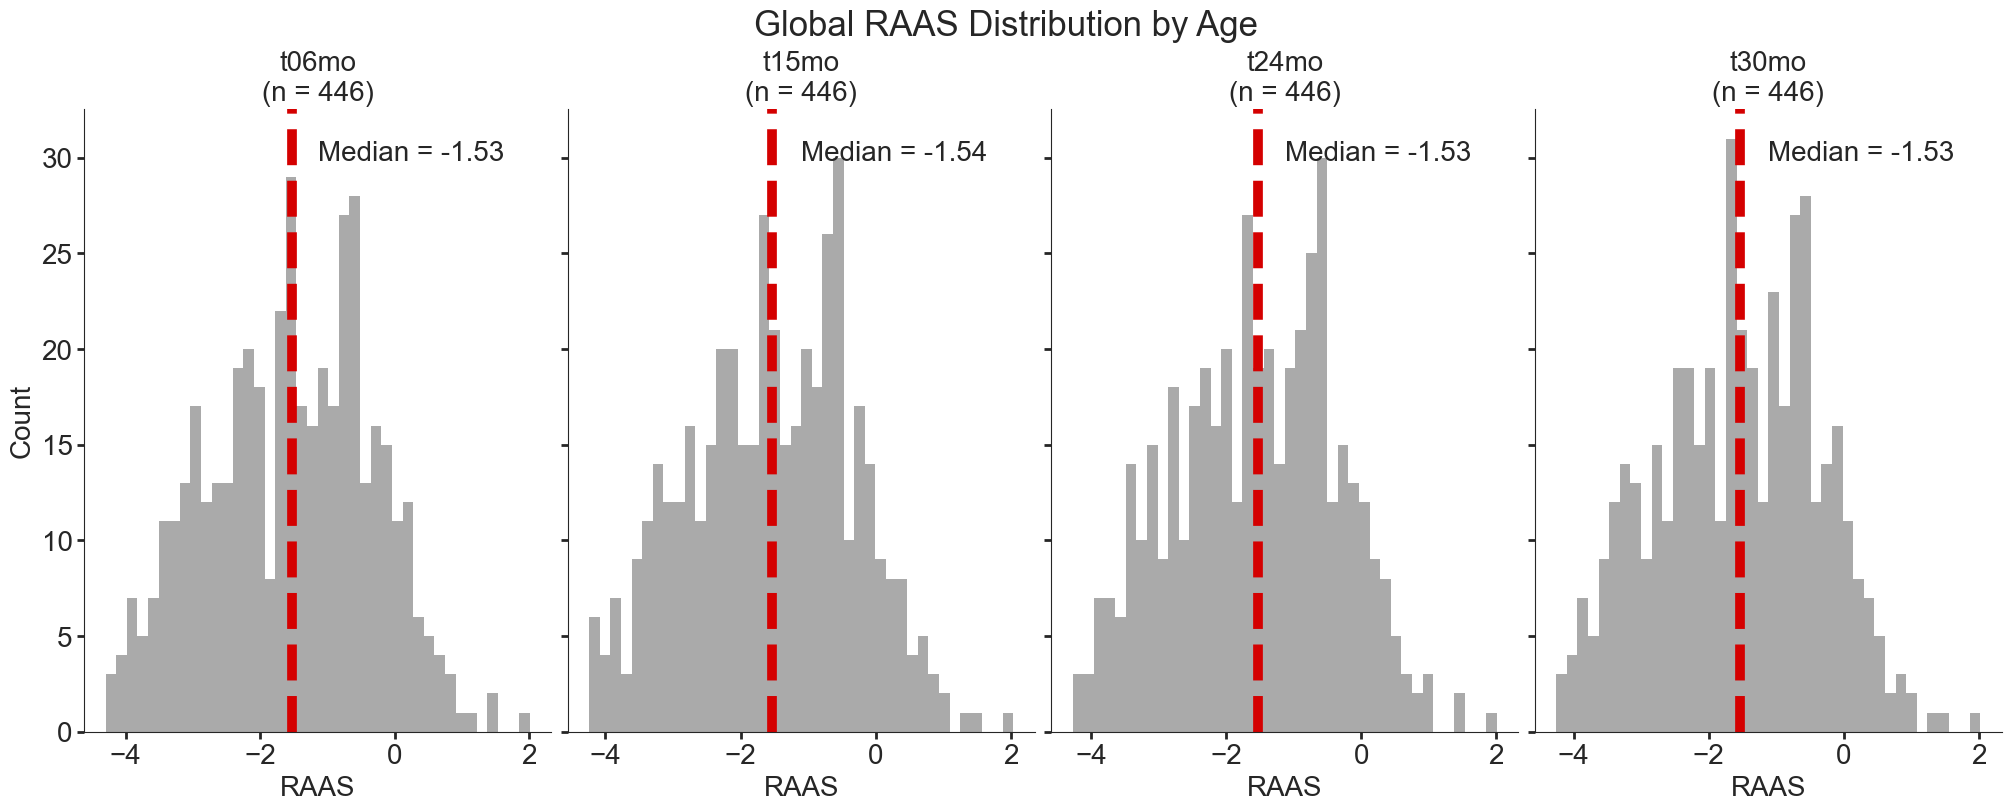

In [36]:
# sample level RAAS distribution by age
# one SAAP RAAS value is the median of its replicates 

age_df = SAAP_quant_df.copy()
age_df = age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = age_df['Sample Type'].unique()
num_ages = len(ages)

fig,axes = plt.subplots(1, num_ages, figsize=(5*num_ages, 8), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    ax = axes[i]
    subset = age_df[age_df['Sample Type'] == age]
    vals = subset['Reporter_RAAS'].values
    vals = vals[np.isfinite(vals)] 

    sns.histplot(vals, bins=40, kde=False, ax=ax,
                 color='#aaaaaa', edgecolor=None, linewidth=0,alpha=1)

    median = np.median(vals)
    ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

    n = len(vals)
    ax.set_title(f'{age}\n(n = {n})', fontsize=20)
    ax.tick_params(axis='both', labelsize=20, length=5, width=2)
    ax.set_xlabel('RAAS', fontsize=20)
    ax.set_ylabel('Count', fontsize=20)
    ax.grid(False)
    sns.despine()

    ax.text(0.5, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
            fontsize=20, verticalalignment='top')

plt.suptitle('Global RAAS Distribution by Age',fontsize=25)
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.png', dpi=600, bbox_inches='tight')

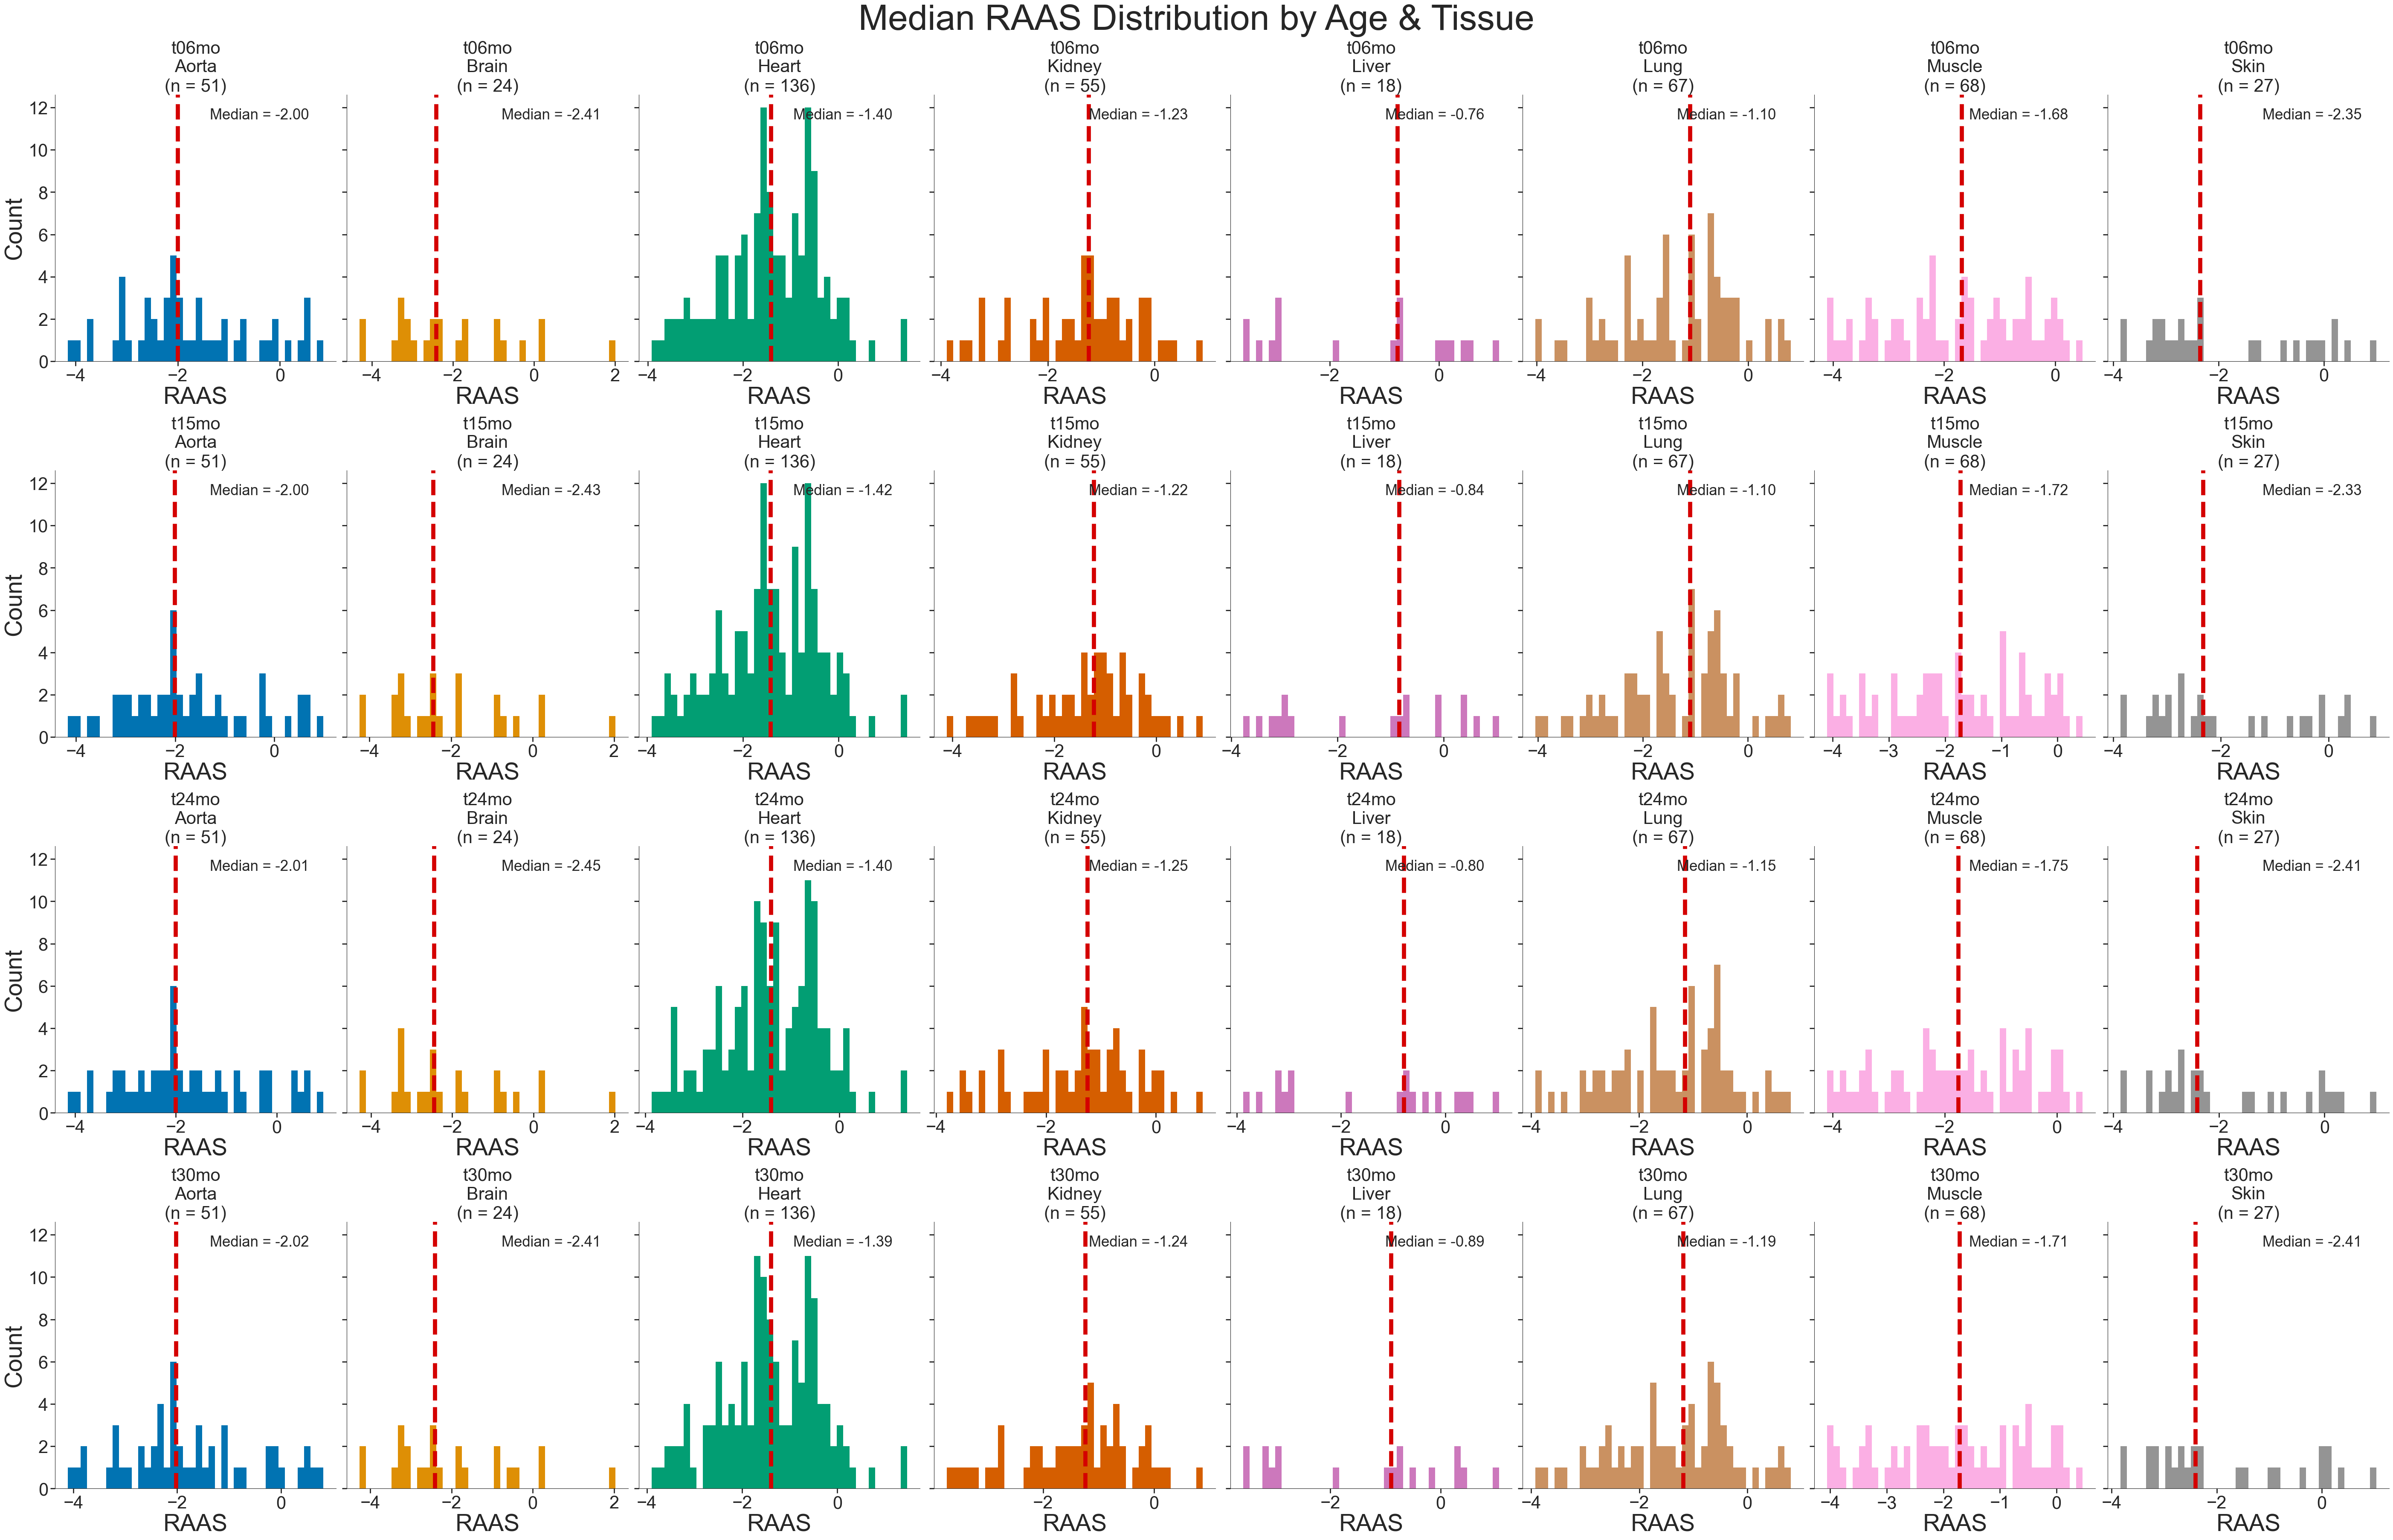

In [37]:
# sample level RAAS distribution by tissue by age
# one SAAP RAAS value is the median of its replicates 

tissue_age_df = SAAP_quant_df.copy()
tissue_age_df = tissue_age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = tissue_age_df['Sample Type'].unique()
tissues = tissue_age_df['Dataset'].unique()

palette = sns.color_palette('colorblind', len(tissues))
tissue_colors = {
    tissue: palette[i]
    for i, tissue in enumerate(tissues)
}

num_ages = len(ages)
num_tissues = len(tissues)

fig,axes = plt.subplots(num_ages, num_tissues, figsize=(7*num_tissues, 9*num_ages), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    for j, tissue in enumerate(tissues):
        ax = axes[i,j]
        subset = tissue_age_df[(tissue_age_df['Sample Type'] == age) &
                               (tissue_age_df['Dataset'] == tissue)]
        vals = subset['Reporter_RAAS'].values
        vals = vals[np.isfinite(vals)]   

        sns.histplot(vals, bins=40, kde=False, ax=ax,
                     color=tissue_colors[tissue], edgecolor=None, linewidth=0,alpha=1)

        median = np.median(vals) if len(vals) else np.nan
        ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

        n = len(vals)
        ax.set_title(f'{age}\n{tissue}\n(n = {n})', fontsize=30)
        ax.tick_params(axis='both', labelsize=30, length=8, width=2)
        ax.set_xlabel('RAAS', fontsize=40)
        ax.set_ylabel('Count', fontsize=40)
        ax.grid(False)
        sns.despine()

        ax.text(0.55, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
                fontsize=25, verticalalignment='top')

plt.suptitle('Median RAAS Distribution by Age & Tissue',fontsize=60)

plt.savefig(PLOT_DIR + 'Global_RAAS_by_agextissue.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Global_RAAS_by_agextissue.png', dpi=600, bbox_inches='tight')

# 3. RAAS Changes Associated with Aging

## 3a Data pre-processing

In [38]:
COMPLETE_SAAPS_ONLY = True # toggle True if wanting SAAPs detected in EVERY age group
SAAP_KEYS     = ['MTP_seq', 'BP_seq', 'aa_sub']   
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

# Functions to prepare data for analysis
def data_prep(df):
    saap_df = df.copy()
    saap_df['Replicate'] = saap_df['Sample'].str.extract(r'_rep(\d+)_',expand=False)
    saap_df['Replicate'] = pd.to_numeric(saap_df['Replicate'], errors='coerce')
    saap_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
    return saap_df

def filter_complete_saaps(df, *, age_col='Age', saap_keys=SAAP_KEYS,
                          within=None, complete_only=None):
    complete_only = COMPLETE_SAAPS_ONLY if complete_only is None else complete_only
    if not complete_only or age_col not in df.columns:
        return df
    grp = (within or []) + list(saap_keys)
    states = [a for a in age_order if a in df[age_col].unique()]
    present = (df[grp + [age_col]].drop_duplicates()
               .groupby(grp, observed=True)[age_col].nunique())
    keep = present[present == len(states)].reset_index()[grp]
    return df.merge(keep, on=grp, how='inner')

In [39]:
# Prepare data for analysis
SAAP_quant_df = data_prep(SAAP_quant_df) # Add replicate number columns for statistics
SAAP_quant_df=filter_complete_saaps(SAAP_quant_df) # Keep only SAAPs seen across all age groups
print(SAAP_quant_df)

      Dataset    MTP_seq     BP_seq  aa_sub tmt_set  Positional_probability  \
0       Aorta  SALSGLLHR  AALSGLLHR  A to S      S1                   0.985   
1       Aorta  SALSGLLHR  AALSGLLHR  A to S      S1                   0.985   
2       Aorta  SALSGLLHR  AALSGLLHR  A to S      S1                   0.985   
3       Aorta  SALSGLLHR  AALSGLLHR  A to S      S1                   0.985   
4       Aorta  SALSGLLHR  AALSGLLHR  A to S      S1                   0.985   
...       ...        ...        ...     ...     ...                     ...   
18187    Skin  INQLYEQSK  INQLYEQAK  A to S      S8                   0.995   
18188    Skin  INQLYEQSK  INQLYEQAK  A to S      S8                   0.995   
18189    Skin  INQLYEQSK  INQLYEQAK  A to S      S8                   0.995   
18190    Skin  INQLYEQSK  INQLYEQAK  A to S      S8                   0.995   
18191    Skin  INQLYEQSK  INQLYEQAK  A to S      S8                   0.995   

       SAAP_PEP        BP_PEP  MTP_PrecInt   BP_Pre

In [40]:
# create dictionary with fold changes for each SAAP's RAAS computed between normal (young) and aged samples
# Adapted from the human tumor-vs-normal design (Code_for_Figure_5), but mouse cohorts are CROSS-SECTIONAL:
# 4 independent replicate mice per age group, so there is NO within-subject pairing. The comparison unit is
# therefore the GROUP, not the mouse: each aged age-group summary is compared to the YOUNG (t06mo) group
# summary, per SAAP -> one fold change per (SAAP, aged timepoint).
#   Log2 Aged/Young RAAS = (agg(log10_RAAS_aged) - agg(log10_RAAS_young)) * log2(10)
# Input SAAP_quant_df is already replicate-tagged (and optionally completeness-filtered) in the cells above.

AGG        = 'mean'                 # group summary stat: 'mean' matches normalize_logfc (Ping); 'median' is outlier-robust
BASELINE   = 't06mo'                # young baseline age group (value in 'Sample Type')
AGE_COL    = 'Sample Type'          # age axis (this dataset has no separate 'Age' column)
SAAP_ABUND = 'MTP_ReportInt_Norm'   # normalized SAAP (MTP) report intensity -> SAAP abundance
BP_ABUND   = 'BP_ReportInt_Norm'    # normalized base-peptide report intensity -> BP abundance
FC_OUTFILE = 'Aged_v_Young_RAAS_fold_change_data.p'

def build_aging_fold_change_dict(df, *, agg=AGG, baseline=BASELINE, saap_keys=SAAP_KEYS, age_col=AGE_COL):
    # {tissue: DataFrame of per-SAAP log2 fold changes, aged age-group summary vs the young (t06mo) summary}
    out = {}
    for tissue in sorted(df['Dataset'].dropna().unique()):
        t_df = df.loc[df['Dataset'] == tissue]

        # per-SAAP, per-age-group summary (mean or median of RAAS / abundances; rep count is always a count)
        grp = (t_df.groupby(saap_keys + [age_col], observed=True)
                   .agg(raas=('Reporter_RAAS', agg), saap=(SAAP_ABUND, agg),
                        bp=(BP_ABUND, agg), n=('Sample', 'nunique'))
                   .reset_index())

        young = (grp.loc[grp[age_col] == baseline].drop(columns=age_col)
                    .rename(columns={'raas': 'young_raas', 'saap': 'young_saap',
                                     'bp': 'young_bp', 'n': 'n_young'}))
        aged = grp.loc[grp[age_col] != baseline].merge(young, on=saap_keys, how='inner')
        if aged.empty:
            out[tissue] = pd.DataFrame()
            print(f"{tissue}: no SAAPs with a {baseline} baseline")
            continue

        # RAAS is already log10, so the log2 fold change is a scaled difference
        aged['Log2 Aged/Young RAAS'] = (aged['raas'] - aged['young_raas']) * np.log2(10)
        aged['Log2 Aged/Young SAAP'] = np.log2(aged['saap'] / aged['young_saap'])
        aged['Log2 Aged/Young BP']   = np.log2(aged['bp']   / aged['young_bp'])
        aged['Dataset'] = tissue
        aged['Baseline'] = baseline
        # zero report intensities produce +/-inf log ratios; treat them as missing
        aged = aged.replace([np.inf, -np.inf], np.nan)

        out[tissue] = aged.rename(columns={
            age_col: 'Age group', 'raas': 'Aged RAAS', 'saap': 'Aged SAAP', 'bp': 'Aged BP',
            'young_saap': 'Young SAAP', 'young_bp': 'Young BP', 'young_raas': 'Young RAAS',
            'n': 'n aged reps', 'n_young': 'n young reps'})[[
            'Dataset', *saap_keys, 'Age group', 'Baseline',
            'Aged SAAP', 'Young SAAP', 'Log2 Aged/Young SAAP',
            'Aged BP',   'Young BP',   'Log2 Aged/Young BP',
            'Aged RAAS', 'Young RAAS', 'Log2 Aged/Young RAAS',
            'n aged reps', 'n young reps']]
        print(f"{tissue}: {len(out[tissue]):,} (SAAP x aged-timepoint) fold changes "
              f"across {out[tissue][saap_keys].drop_duplicates().shape[0]} SAAPs")
    return out

aging_fc_dict = build_aging_fold_change_dict(SAAP_quant_df)
pickle.dump(aging_fc_dict, open(OUTDIR + FC_OUTFILE, 'wb'))
print(f"\nWrote {OUTDIR + FC_OUTFILE} (group summary: {AGG})")

Aorta: 168 (SAAP x aged-timepoint) fold changes across 56 SAAPs
Brain: 81 (SAAP x aged-timepoint) fold changes across 27 SAAPs
Heart: 423 (SAAP x aged-timepoint) fold changes across 141 SAAPs
Kidney: 189 (SAAP x aged-timepoint) fold changes across 63 SAAPs
Liver: 66 (SAAP x aged-timepoint) fold changes across 22 SAAPs
Lung: 219 (SAAP x aged-timepoint) fold changes across 73 SAAPs
Muscle: 216 (SAAP x aged-timepoint) fold changes across 72 SAAPs
Skin: 87 (SAAP x aged-timepoint) fold changes across 29 SAAPs

Wrote /Users/alexmaropakis/Projects/BrainDecode/Dependencies/Analysis_Outputs/Takasugi_2024/Aged_v_Young_RAAS_fold_change_data.p (group summary: mean)


## 3b RAAS fold change distributions

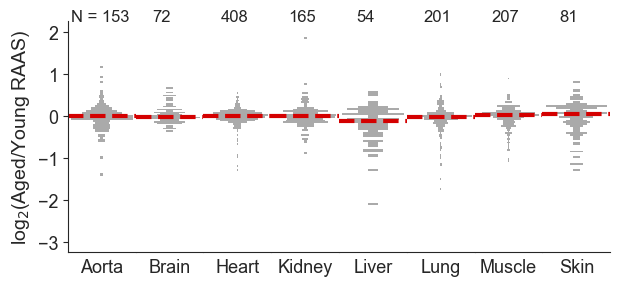

In [41]:
# plot overall distribution of aged vs young RAAS fold change for each SAAP, per tissue
# pools all (SAAP x aged-timepoint) fold changes within a tissue (mirrors the human per-patient pooling)
# aging_fc_dict = pickle.load(open(OUTDIR+'Aged_v_Young_RAAS_fold_change_data.p','rb'))
fc_dict = aging_fc_dict
fc_tissues = [t for t in datasets if t in fc_dict and not fc_dict[t].empty]

col2plot = 'Log2 Aged/Young RAAS'

sns.set_style('ticks')
fig, axes = plt.subplots(1, len(fc_tissues), figsize=(7, 3), sharey=True)

plt.subplots_adjust(wspace=0)
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False, labelbottom=False)
    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# sort tissues in plot by median of distribution
medians = []
for t in fc_tissues:
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    medians.append(np.median(data))
# med_sort_idx = list(np.argsort(medians))
med_sort_idx = [tissue_order.index(ds) for ds in datasets]

for i, t in enumerate(fc_tissues):
    # print(t)
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(t, fontsize=13)
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    bihist(data, data, nbins=70, h=axes[ax_idx])
    if ax_idx == 0:
        axes[ax_idx].annotate('N = '+str(len(data)), (0.05, 1), xycoords='axes fraction', fontsize=12)
    else:
        axes[ax_idx].annotate(str(len(data)), (0.25, 1), xycoords='axes fraction', fontsize=12)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(data), np.median(data)), '--', color='#d40000', linewidth=3)
axes[0].set_ylabel('log$_2$(Aged/Young RAAS)', fontsize=14)
axes[0].tick_params('both', labelsize=13)

plt.savefig(PLOT_DIR + 'Aged_v_Young_RAAS_bihist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Aged_v_Young_RAAS_bihist.png', dpi=600, bbox_inches='tight')

## 3c Per-SAAP pairwise RAAS significance with age

### Assumption Diagnostics

In [42]:
print(tissue_order) # defined earlier but re-define here if needed 
# tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']
SAAP_KEYS     = ['MTP_seq', 'BP_seq', 'aa_sub']   
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
baseline = 't06mo' # young/healthy age 
aged = [x for x in age_order if x != baseline] # comparison groups  
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']
min_reps = 3 # min number of replicates present for a SAAP to conduct any test 
sig = 0.05 # significance cap 
USE_FDR = False # Option to toggle on BH-FDR correction and the type of statistical test used 

['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']


In [43]:
def sig_col(): return 'FDR' if USE_FDR else 'p_value'
def sig_label(): return 'FDR' if USE_FDR else 'p'

# tidy replicate table: one finite log10 RAAS per (tissue, SAAP, mouse)
raas_rep_df = SAAP_quant_df[['Dataset', *SAAP_KEYS, 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_rep_df['Reporter_RAAS'] = pd.to_numeric(raas_rep_df['Reporter_RAAS'], errors='coerce')
raas_rep_df = raas_rep_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])

# Helper functions
def run_fdr(df, p_col, out_col='FDR'):
    # Benjamini-Hochberg across rows, preserving NaN p-values 
    df = df.copy()
    df[out_col] = np.nan 
    ok = df[p_col].notna()
    if ok.any():
        df.loc[ok, out_col] = multipletests(df.loc[ok, p_col], method='fdr_bh')[1]
    return df  

def fdr_within(df, p_col, group_col, out_col='FDR'):
    # BH-FDR across SAAPs within each age group/comparison
    if df.empty:
        return df
    return pd.concat([run_fdr(g,p_col,out_col) for _, g in df.groupby(group_col)], ignore_index=True)

def iter_saaps(rep=None, age_col='Sample Type'):
    # yield (tissue, saap_key_tuple, {age: RAAS array}, group_df) for each tissue x SAAP 
    rep = raas_rep_df if rep is None else rep
    for (tissue, *keys), g in rep.groupby(['Dataset', *SAAP_KEYS], observed=True):
        by_age = {a: v['Reporter_RAAS'].values for a, v in g.groupby(age_col, observed=True)}
        yield tissue, tuple(keys), by_age, g

def sig_summary(df, p_col, label_col):
    # n significant SAAPs (raw p and FDR) per comparison 
    for lab, g in df.groupby(label_col):
        print(f"    {lab:18} tested={len(g):4d} p<={sig}: {int((g[p_col]<=sig).sum()):4d}"
              f"    FDR<={sig}: {int((g['FDR']<=sig).sum()):4d}")

print(f"{len(raas_rep_df):,} replicate RAAS values across "
      f"{raas_rep_df.groupby(['Dataset',*SAAP_KEYS],observed=True).ngroups:,} tissue x SAAP groups")

7,150 replicate RAAS values across 447 tissue x SAAP groups


### Normality and variance diagnostics for RAAS values across age groups
##### Goal: test whether RAAS changes across age groups
##### Questions: is the data normally distributed? Is the variance equal across groups? 

--- (C) Shapiro-Wilk normality of POOLED residuals (Studentized residual (per-SAAP)), per tissue + global ---
    residual = replicate RAAS - (tissue x SAAP x age) group mean; Shapiro on capped subsample (n <= 300)
 scope  n_sub      W      p    skew  kurtosis      normal?
 Aorta    300 0.9879 0.0128  0.1709    0.0608   NOT normal
 Brain    300 0.9934 0.2156  0.0004   -0.4882 looks normal
 Heart    300 0.9910 0.0624  0.0068   -0.3852 looks normal
Kidney    300 0.9974 0.9136  0.0798   -0.1679 looks normal
 Liver    288 0.9960 0.6764 -0.0315    0.0236 looks normal
  Lung    300 0.9944 0.3369  0.1928   -0.1678 looks normal
Muscle    300 0.9904 0.0471 -0.0528   -0.4069   NOT normal
  Skin    300 0.9920 0.1040  0.1709   -0.0260 looks normal
GLOBAL    300 0.9938 0.2569  0.0613   -0.2457 looks normal

global: W=0.9938, p=0.257 (skew=0.06, kurtosis=-0.25)  ->  looks normal
  -> if residuals look normal, parametric tests on RAAS are justified (the assumption is on residuals).


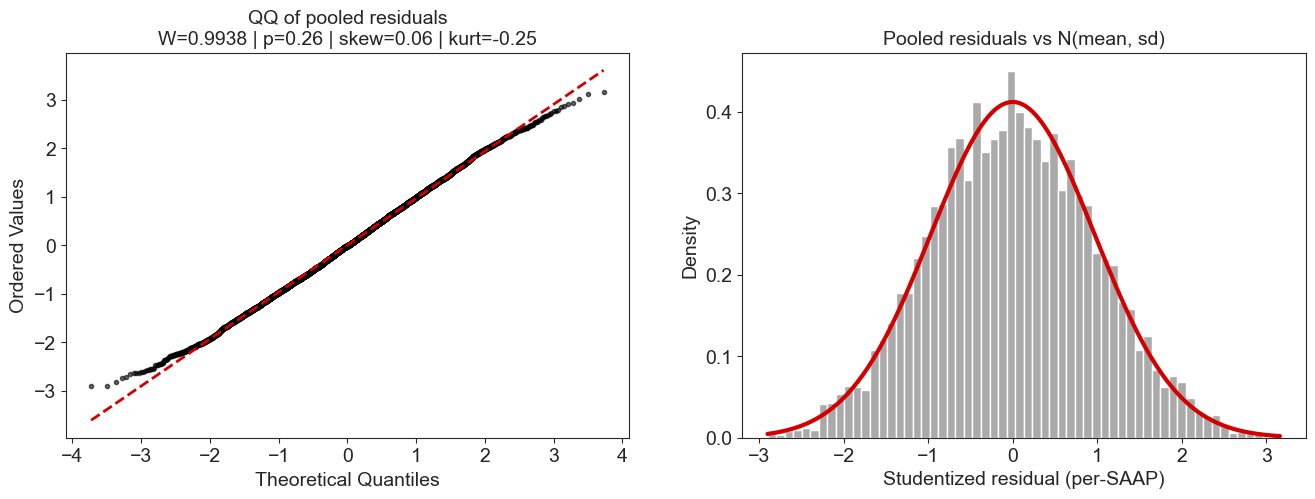

In [44]:
# ============================================================================
# (C) Normality assumption check -- Shapiro-Wilk on POOLED RESIDUALS (the correct way with
# replicates): residual = each replicate's RAAS minus its (tissue x SAAP x age) GROUP MEAN.
# Pool all residuals into ONE sample and test THAT for normality -- parametric tests assume
# the residuals are normal, not the raw values (which differ by group mean). Reporter_RAAS
# is ALREADY log10 -- never re-log. Per tissue + global. Shapiro over-rejects at large n ->
# capped random subsample.
#
# STANDARDIZE_RESIDUALS: different SAAPs have different replicate spreads, so pooling RAW
# residuals mixes scales and creates ARTIFACTUAL heavy tails. Dividing each residual by its
# SAAP's pooled residual SD (Studentizing) removes that artifact -- the proper normality check.
# ============================================================================
STANDARDIZE_RESIDUALS = True
alpha = 0.05; CAP = 300
rng = np.random.RandomState(0)

ds = raas_rep_df.copy()                                  # Reporter_RAAS already log10
ds['resid'] = (ds['Reporter_RAAS']
               - ds.groupby(['Dataset', *SAAP_KEYS, 'Sample Type'], observed=True)['Reporter_RAAS'].transform('mean'))
if STANDARDIZE_RESIDUALS:
    ds['resid'] = ds['resid'] / ds.groupby(['Dataset', *SAAP_KEYS], observed=True)['resid'].transform('std').replace(0, np.nan)
ds = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=['resid'])
rlabel = 'Studentized residual (per-SAAP)' if STANDARDIZE_RESIDUALS else 'raw residual (RAAS - group mean)'

def shapiro_capped(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if len(x) < 3:
        return {'n_sub': len(x), 'W': np.nan, 'p': np.nan, 'skew': np.nan, 'kurtosis': np.nan}
    xs = rng.choice(x, CAP, replace=False) if len(x) > CAP else x
    W, p = stats.shapiro(xs)
    return {'n_sub': len(xs), 'W': W, 'p': p, 'skew': stats.skew(x), 'kurtosis': stats.kurtosis(x)}

tissues = [t for t in tissue_order if t in ds['Dataset'].unique()]
recs = [{'scope': t, **shapiro_capped(ds.loc[ds['Dataset'] == t, 'resid'])} for t in tissues]
recs.append({'scope': 'GLOBAL', **shapiro_capped(ds['resid'])})
shap_df = pd.DataFrame(recs)
shap_df['normal?'] = np.where(shap_df['p'] > alpha, 'looks normal', 'NOT normal')

print(f"--- (C) Shapiro-Wilk normality of POOLED residuals ({rlabel}), per tissue + global ---")
print(f"    residual = replicate RAAS - (tissue x SAAP x age) group mean; Shapiro on capped subsample (n <= {CAP})")
print(shap_df.round(4).to_string(index=False))
g = shap_df[shap_df['scope'] == 'GLOBAL'].iloc[0]
print(f"\nglobal: W={g['W']:.4f}, p={g['p']:.3g} (skew={g['skew']:.2f}, kurtosis={g['kurtosis']:.2f})  ->  {g['normal?']}")
print("  -> if residuals look normal, parametric tests on RAAS are justified (the assumption is on residuals).")

# QQ + histogram on the GLOBAL pooled residuals (native scale, N(mean,sd) overlay)
vals = ds['resid'].to_numpy(); vals = vals[np.isfinite(vals)]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
stats.probplot(vals, dist='norm', plot=ax[0])
ax[0].get_lines()[0].set(color='#000000', ms=3, alpha=0.6)
ax[0].get_lines()[1].set(color='#d40000', lw=2, ls='--')
ax[0].set_title(f'QQ of pooled residuals\nW={g["W"]:.4f} | p={g["p"]:.2g} | '
                f'skew={stats.skew(vals):.2f} | kurt={stats.kurtosis(vals):.2f}', fontsize=14)
ax[0].set_xlabel('Theoretical Quantiles', fontsize=14); ax[0].set_ylabel('Ordered Values', fontsize=14)
ax[0].tick_params(axis='both', labelsize=14)
mu, sdv = vals.mean(), vals.std()
xs = np.linspace(vals.min(), vals.max(), 200)
ax[1].hist(vals, bins=60, density=True, color='#aaaaaa')
ax[1].plot(xs, stats.norm.pdf(xs, mu, sdv), color='#d40000', lw=3)
ax[1].set_title('Pooled residuals vs N(mean, sd)', fontsize=14)
ax[1].set_xlabel(rlabel, fontsize=14); ax[1].set_ylabel('Density', fontsize=14)
ax[1].tick_params(axis='both', labelsize=14)
plt.savefig(PLOT_DIR + 'Aging_RAAS_normality.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'Aging_RAAS_normality.png', dpi=600, bbox_inches='tight')
plt.show()


### Is the within-group variance of RAAS the same across 4 age groups? 

In [45]:
"""
QUESTION: does the WITHIN-AGE-GROUP RAAS distribution change in spread (variance) over
aging -- per tissue AND globally?

UNIT = AGE GROUP. The replicate mice are NOT the unit -- they only sharpen each SAAP's
estimate -- so we COLLAPSE them: one RAAS per (tissue, SAAP, age) = mean over replicates.
Within an age group we then have the distribution of per-SAAP RAAS (the RAAS "landscape");
we test whether the SPREAD of that distribution differs across the 4 ages. This removes
the replicate-level pseudoreplication that otherwise inflates n and flags trivial
differences as significant.

  - No SAAP-centering. Reporter_RAAS is ALREADY log10 -- never re-log.
  - Levene (Brown-Forsythe) + Fligner-Killeen across ages; neither assumes normality.
  - BH-FDR across the 8 tissues; GLOBAL kept out of that family.
  - n per age group = number of SAAPs measured at that age (NOT x replicates).
"""
import scipy.stats as stats

AGG = 'mean'   # collapse replicate mice -> one RAAS per (tissue, SAAP, age). 'mean' = best estimate; 'median' = robust

d = raas_rep_df.copy()                                   # Reporter_RAAS already log10
raas_age = (d.groupby(['Dataset', *SAAP_KEYS, 'Sample Type'], observed=True)['Reporter_RAAS']
            .agg(AGG).reset_index())                     # one row per tissue x SAAP x age
raas_age = raas_age.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])

def variance_across_ages(df):
    """Levene (Brown-Forsythe) + Fligner-Killeen on per-SAAP RAAS across the age groups."""
    groups = [g['Reporter_RAAS'].values for _, g in df.groupby('Sample Type', observed=True) if len(g) >= 2]
    n_saap = df.drop_duplicates(subset=SAAP_KEYS).shape[0]
    if len(groups) < 2:
        return {'n_saap': n_saap, 'n_pts': len(df), 'levene_p': np.nan, 'fligner_p': np.nan}
    return {'n_saap': n_saap, 'n_pts': int(sum(map(len, groups))),
            'levene_p':  stats.levene(*groups, center='median').pvalue,
            'fligner_p': stats.fligner(*groups).pvalue}

tissues = [t for t in tissue_order if t in raas_age['Dataset'].unique()]
recs = [{'scope': t, **variance_across_ages(raas_age[raas_age['Dataset'] == t])} for t in tissues]
recs.append({'scope': 'GLOBAL', **variance_across_ages(raas_age)})
var_df = pd.DataFrame(recs)

ok = (var_df['scope'] != 'GLOBAL') & var_df['levene_p'].notna()
for c in ['levene', 'fligner']:
    var_df.loc[ok, f'{c}_FDR'] = multipletests(var_df.loc[ok, f'{c}_p'], method='fdr_bh')[1]
var_df['verdict'] = np.where(var_df['levene_p'] <= sig, 'variance DIFFERS across ages', 'no detected difference')

cols = ['scope', 'n_saap', 'n_pts', 'levene_p', 'fligner_p', 'levene_FDR', 'fligner_FDR', 'verdict']
print(f"--- Within-age-group RAAS variance across ages (replicates collapsed by {AGG}); Levene + Fligner, log10 RAAS ---")
print("    unit = one RAAS per (tissue x SAAP x age);  n_saap = unique SAAPs;  n_pts = SAAP x age points")
print(var_df[cols].round(4).to_string(index=False))
tis = var_df[var_df['scope'] != 'GLOBAL']; g = var_df[var_df['scope'] == 'GLOBAL'].iloc[0]
n_sig = int((tis['levene_FDR'] <= sig).sum())
print(f"\nper tissue: {n_sig}/{int(tis['levene_p'].notna().sum())} tissues show UNEQUAL variance (Levene BH-FDR<={sig})")
print(f"global:     Levene p={g['levene_p']:.3g}, Fligner p={g['fligner_p']:.3g}  ->  {g['verdict']}")


--- Within-age-group RAAS variance across ages (replicates collapsed by mean); Levene + Fligner, log10 RAAS ---
    unit = one RAAS per (tissue x SAAP x age);  n_saap = unique SAAPs;  n_pts = SAAP x age points
 scope  n_saap  n_pts  levene_p  fligner_p  levene_FDR  fligner_FDR                verdict
 Aorta      51    204    0.9997     0.9997         1.0          1.0 no detected difference
 Brain      24     96    0.9999     0.9931         1.0          1.0 no detected difference
 Heart     136    544    0.9999     0.9991         1.0          1.0 no detected difference
Kidney      55    220    0.9986     0.9917         1.0          1.0 no detected difference
 Liver      18     72    0.9988     0.9911         1.0          1.0 no detected difference
  Lung      67    268    1.0000     1.0000         1.0          1.0 no detected difference
Muscle      69    276    0.9983     0.9929         1.0          1.0 no detected difference
  Skin      27    108    0.9973     0.9985         1.0        

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3211621019.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

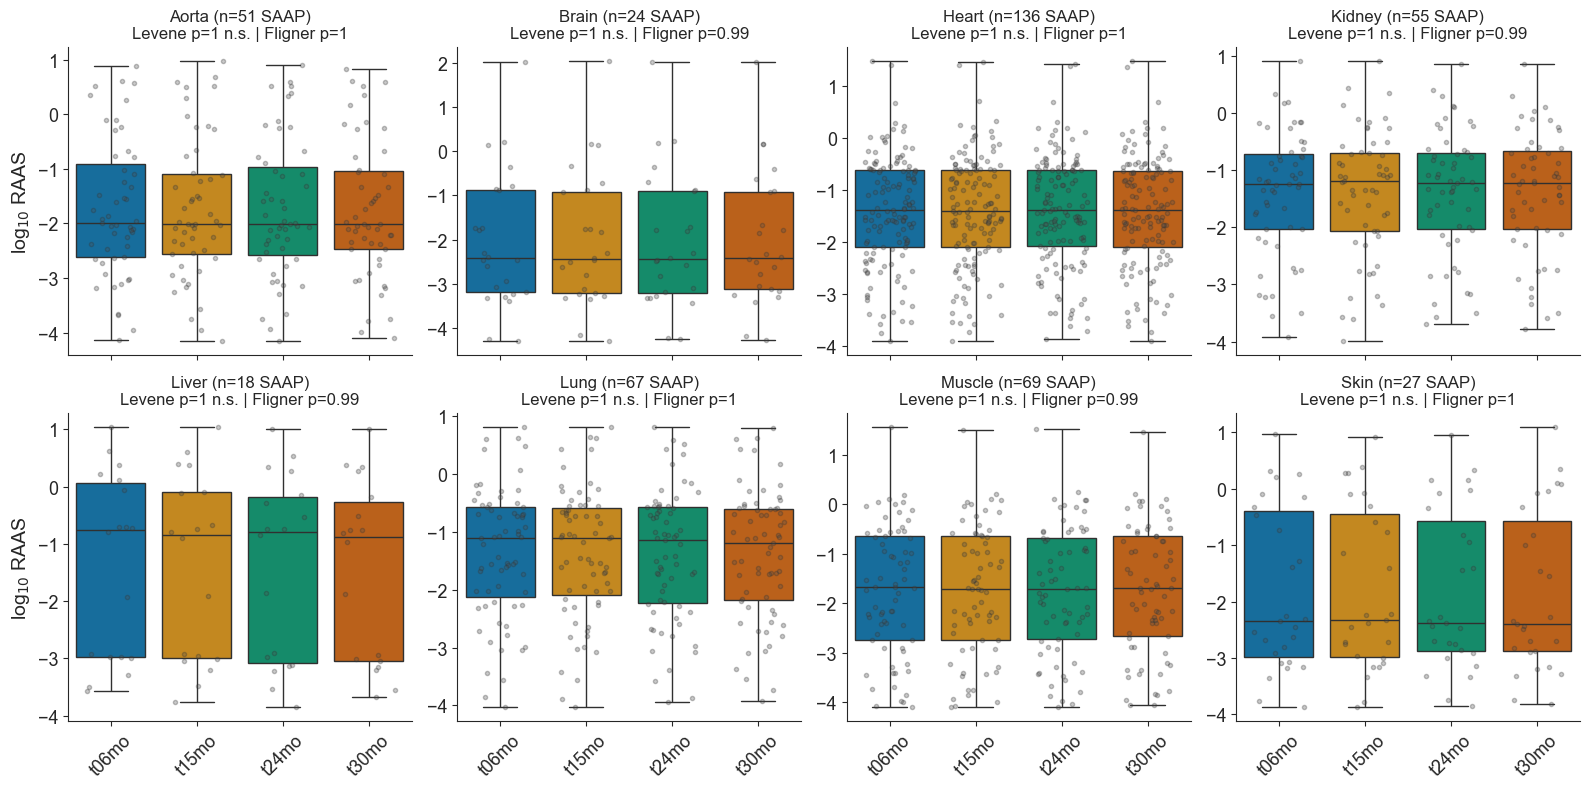

In [46]:
# Within-age-group RAAS spread across ages, PER TISSUE (2 rows x 4 cols).
# Each point = one SAAP's replicate-collapsed RAAS; box = the RAAS distribution at
# that age. Equal box heights across ages = equal variance. n = unique SAAPs.

sns.set_style('ticks')

def sig_stars(p):
    return ('***' if p <= 1e-3 else '**' if p <= 1e-2 else '*' if p <= 5e-2 else 'n.s.') if pd.notna(p) else 'NA'

ncol = 4; nrow = int(np.ceil(len(tissues) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow), sharex=True)
axes = np.atleast_1d(axes).reshape(-1)
for i, (ax, t) in enumerate(zip(axes, tissues)):
    dd = raas_age[raas_age['Dataset'] == t]
    sns.boxplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
                linewidth=1, fliersize=0, ax=ax)
    sns.stripplot(data=dd, x='Sample Type', y='Reporter_RAAS', order=age_order, ax=ax,
                  color='#525252', size=3, alpha=0.3, jitter=0.3, linewidth=1)
    r = var_df[var_df['scope'] == t].iloc[0]
    ax.set_title(f"{t} (n={int(r['n_saap'])} SAAP)\n"
                 f"Levene p={r['levene_p']:.2g} {sig_stars(r.get('levene_FDR', np.nan))} | Fligner p={r['fligner_p']:.2g}",
                 fontsize=12)
    ax.set_xlabel(''); ax.set_ylabel('log$_{10}$ RAAS' if i % ncol == 0 else '', fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    sns.despine(ax=ax)
for ax in axes[len(tissues):]:
    ax.set_visible(False)
fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_variance_by_tissue.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_variance_by_tissue.png', dpi=600, bbox_inches='tight')
plt.show()


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/3757211738.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',


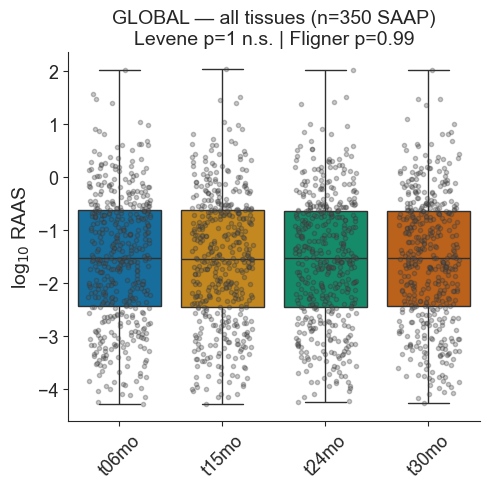

In [47]:
# Within-age-group RAAS spread across ages, GLOBAL (all tissues pooled, replicates collapsed).

sns.set_style('ticks')

def sig_stars(p):
    return ('***' if p <= 1e-3 else '**' if p <= 1e-2 else '*' if p <= 5e-2 else 'n.s.') if pd.notna(p) else 'NA'

g = var_df[var_df['scope'] == 'GLOBAL'].iloc[0]
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, palette='colorblind',
            linewidth=1, fliersize=0, ax=ax)
sns.stripplot(data=raas_age, x='Sample Type', y='Reporter_RAAS', order=age_order, ax=ax,
              color='#525252', size=3, alpha=0.3, jitter=0.3, linewidth=1)
ax.set_title(f"GLOBAL — all tissues (n={int(g['n_saap'])} SAAP)\n"
             f"Levene p={g['levene_p']:.2g} {sig_stars(g['levene_p'])} | Fligner p={g['fligner_p']:.2g}", fontsize=14)
ax.set_xlabel(''); ax.set_ylabel('log$_{10}$ RAAS', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=13)
ax.tick_params(axis='y', labelsize=13)
sns.despine(ax=ax)
fig.tight_layout()
plt.savefig(PLOT_DIR + 'RAAS_variance_global.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'RAAS_variance_global.png', dpi=600, bbox_inches='tight')
plt.show()


### What are the significant SAAP-level changes with aging within tissues?

In [48]:
# 3c  Per-SAAP pairwise Student's t-test of log10 RAAS: each aged age vs the 6mo (t06mo) baseline,
#      WITHIN each tissue. Equal-variance (Student) is justified by the diagnostics above -- pooled
#      residuals are ~normal (Shapiro/QQ, cell 66) and the within-age-group RAAS variance is homogeneous
#      across ages (Levene/Fligner, cell 68). At balanced n=4 the equal-variance pooling recovers the
#      degrees of freedom and power that Welch would forfeit.
#
# Toggles:
#   EQUAL_VAR (here)     -- True = Student's t (equal variance, the justified default); False = Welch's t.
#   USE_FDR (setup cell) -- multiple-hypothesis-correction toggle. BH-FDR is computed across SAAPs *within*
#                           each comparison (the multiplicity family); USE_FDR then flips sig_col()/sig_label()
#                           so every downstream significance call + label uses FDR vs raw p. FDR is always
#                           stored, so the toggle never recomputes -- it only re-points the threshold.
#
# `aging_ttest_df` is the tidy, publication-ready source frame for Supplemental_Data_3 (one row per
# tissue x SAAP x comparison): group means/SDs, log2 fold change, direction, t/df, p_value and FDR.

EQUAL_VAR = True          # Student's t (equal variance); flip to False for Welch's t

def pairwise_student_ttest(rep=None, *, equal_var=EQUAL_VAR):
    """Each aged age vs the t06mo baseline, per (tissue x SAAP), via a two-sample t-test on log10 RAAS.
    BH-FDR is added across SAAPs within each comparison. rep=None -> per-tissue (groups by Dataset x SAAP);
    pass a pooled rep (single Dataset) for an across-tissue cohort."""
    test_name = 'Student' if equal_var else 'Welch'
    rows = []
    for tissue, keys, by_age, _ in iter_saaps(rep):
        base = by_age.get(baseline, np.empty(0))
        if len(base) < min_reps:                       # need the baseline group to test against
            continue
        for a in aged:
            cur = by_age.get(a, np.empty(0))
            if len(cur) < min_reps:                    # skip aged timepoints with too few replicates
                continue
            res = ttest_ind(cur, base, equal_var=equal_var)
            df_t = float(getattr(res, 'df', len(cur) + len(base) - 2))   # scipy>=1.11 exposes .df
            rows.append({
                'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
                'comparison': f'{a} vs {baseline}',
                'n_base': len(base), 'n_aged': len(cur),
                'mean_young_RAAS': base.mean(), 'mean_aged_RAAS': cur.mean(),
                'sd_young_RAAS': base.std(ddof=1), 'sd_aged_RAAS': cur.std(ddof=1),
                'mean_log2FC': (cur.mean() - base.mean()) * np.log2(10),   # RAAS is already log10
                't_stat': float(res.statistic), 'df': df_t, 'p_value': float(res.pvalue),
                'test': test_name})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')   # BH-FDR across SAAPs within comparison
    if not out.empty:
        out['direction'] = np.where(out['mean_log2FC'] >= 0, 'up', 'down')
        out['significant'] = out[sig_col()] <= sig                 # flagged by the active metric (p or FDR)
    return out

aging_ttest_df = pairwise_student_ttest()
pickle.dump(aging_ttest_df, open(OUTDIR + 'Aging_RAAS_pairwise_ttest.p', 'wb'))

print(f"Pairwise {'Student' if EQUAL_VAR else 'Welch'}'s t-test of log10 RAAS, each aged age vs {baseline}, within tissues")
print(f"  multiplicity = BH-FDR across SAAPs within each comparison | significance = {sig_label()} <= {sig}")
print(f"  tested {len(aging_ttest_df):,} (tissue x SAAP x comparison) over "
      f"{aging_ttest_df[['Dataset', *SAAP_KEYS]].drop_duplicates().shape[0]:,} tissue x SAAP groups\n")
sig_summary(aging_ttest_df, 'p_value', 'comparison')

# preview: most significant changers first (display-only formatting; stored columns stay numeric)
_show = ['Dataset', 'aa_sub', 'comparison', 'n_aged', 'mean_log2FC', 'direction', 't_stat', 'p_value', 'FDR']
_prev = aging_ttest_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f'{v:.2e}' if pd.notna(v) else '')
_prev['mean_log2FC'] = _prev['mean_log2FC'].map(lambda v: f'{v:+.3f}')
print(f"\ntop changers by {sig_label()}:")
print(_prev[_show].to_string(index=False))


Pairwise Student's t-test of log10 RAAS, each aged age vs t06mo, within tissues
  multiplicity = BH-FDR across SAAPs within each comparison | significance = p <= 0.05
  tested 1,341 (tissue x SAAP x comparison) over 447 tissue x SAAP groups

    t15mo vs t06mo     tested= 447 p<=0.05:   53    FDR<=0.05:    0
    t24mo vs t06mo     tested= 447 p<=0.05:   69    FDR<=0.05:   12
    t30mo vs t06mo     tested= 447 p<=0.05:   84    FDR<=0.05:   12

top changers by p:
Dataset   aa_sub     comparison  n_aged mean_log2FC direction     t_stat  p_value      FDR
 Muscle   A to S t30mo vs t06mo       4      +0.343        up  14.644136 6.37e-06 2.85e-03
   Skin   A to S t30mo vs t06mo       4      +0.822        up  11.869767 2.16e-05 4.83e-03
   Skin   H to E t30mo vs t06mo       4      -1.151      down -10.512721 4.35e-05 6.48e-03
 Muscle   E to T t24mo vs t06mo       4      +0.520        up   9.925557 6.04e-05 2.13e-02
  Liver   I to M t30mo vs t06mo       4      -2.073      down  -9.875677 6.22e-

#### Volcano plot of significant SAAP-level RAAS changes with aging

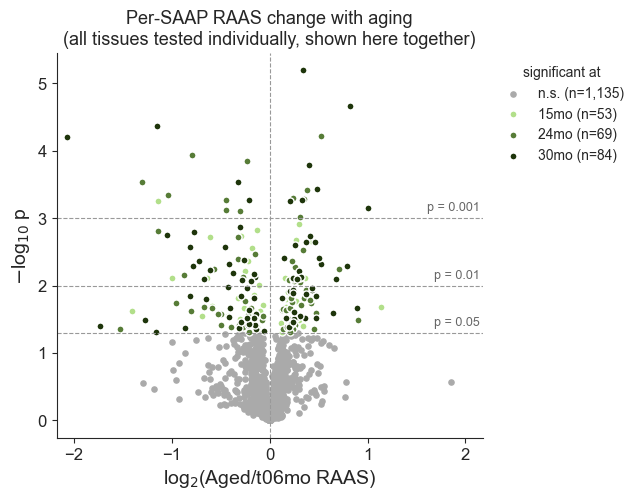


significant SAAP-changes (p <= 0.05) plotted by aged timepoint:
age
t15mo    53
t24mo    69
t30mo    84


In [49]:
# Volcano of per-SAAP RAAS changes with aging -- ALL aged timepoints + tissues pooled into one plot.
#      x = mean log2(Aged/Young RAAS) (cur.mean - base.mean, scaled to log2); y = -log10 of the active
#      significance metric (FDR or raw p, per the USE_FDR toggle, via sig_col()/sig_label()).
#      Non-significant SAAPs are grey; significant SAAPs (sig_col() <= sig) are colored by the aged
#      timepoint they were compared against the 6mo baseline at (15mo / 24mo / 30mo). Each (tissue x SAAP
#      x comparison) row in aging_ttest_df (cell above) is one point, so a SAAP can appear up to 3x
#      (once per aged timepoint). Older timepoints are drawn last so they sit on top.

# aging-timepoint palette (warm ramp deepening with age); grey = not significant
AGE_COLORS = {'t15mo': '#b2df8a', 't24mo': "#577c37", 't30mo': "#1e350b"}
NS_COLOR   = '#aaaaaa'

# horizontal reference lines, drawn at -log10 of each value on the active-metric (sig_col()) axis
# SIG_LINES = [0.05, 0.01, 0.001, 0.0001] # pval
SIG_LINES = [0.05, 0.01, 0.001] # FDR

def plot_aging_volcano(df, *, age_colors=AGE_COLORS, ns_color=NS_COLOR, sig_lines=SIG_LINES):
    metric = sig_col()                                       # 'FDR' or 'p_value' per USE_FDR
    d = df.dropna(subset=['mean_log2FC', metric]).copy()
    d['age'] = d['comparison'].str.split().str[0]            # 't15mo' from 't15mo vs t06mo'
    # -log10 with a floor so a metric value of 0 (numeric underflow) stays finite/on-scale
    floor = d.loc[d[metric] > 0, metric].min()
    d['neglog10'] = -np.log10(d[metric].clip(lower=floor))

    sns.set_style('ticks')
    fig, ax = plt.subplots(figsize=(5.5, 5))

    # non-significant background first (significance set earlier in 3c: sig_col() <= sig)
    ns = d[~d['significant']]
    ax.scatter(ns['mean_log2FC'], ns['neglog10'], s=14, color=ns_color, alpha=1,
               linewidths=1, label=f'n.s. (n={len(ns):,})', rasterized=True)
    # significant SAAPs only, colored by aged timepoint, oldest plotted last (on top)
    for age in [a for a in age_order if a in age_colors]:
        sub = d[d['significant'] & (d['age'] == age)]
        ax.scatter(sub['mean_log2FC'], sub['neglog10'], s=26, color=age_colors[age], alpha=1,
                   linewidths=1, edgecolors='white', label=f'{age[1:]} (n={len(sub):,})')

    xlim = np.nanmax(np.abs(d['mean_log2FC'])) * 1.05         # symmetric x so up/down read evenly
    ax.set_xlim(-xlim, xlim)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')

    # horizontal reference lines at the active metric (FDR or p), labeled at the right edge
    for v in sig_lines:
        y = -np.log10(v)
        ax.axhline(y, color='#999999', lw=0.8, ls='--')
        ax.annotate(f'{sig_label()} = {v:g}', (ax.get_xlim()[1], y),
                    xytext=(-2, 3), textcoords='offset points', ha='right', va='bottom',
                    fontsize=9, color='#666666')

    ax.set_xlabel('log$_2$(Aged/t06mo RAAS)', fontsize=14)
    ax.set_ylabel(f'$-$log$_{{10}}$ {sig_label()}', fontsize=14)
    ax.set_title(f'Per-SAAP RAAS change with aging\n(all tissues tested individually, shown here together)', fontsize=13)
    ax.tick_params('both', labelsize=12)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(title='significant at', fontsize=10, title_fontsize=10, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1))

    plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.pdf', bbox_inches='tight')
    plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.png', dpi=600, bbox_inches='tight')
    plt.show()
    return d

_volcano = plot_aging_volcano(aging_ttest_df)
print(f"\nsignificant SAAP-changes ({sig_label()} <= {sig}) plotted by aged timepoint:")
print(_volcano[_volcano['significant']].groupby('age').size().reindex(aged).fillna(0).astype(int).to_string())

In [50]:
# # Volcano of per-SAAP RAAS changes with aging -- ALL aged timepoints + tissues pooled into one plot.
# #      x = mean log2(Aged/Young RAAS) (cur.mean - base.mean, scaled to log2); y = -log10 of the active
# #      significance metric (FDR or raw p, per the USE_FDR toggle, via sig_col()/sig_label()).
# #      Non-significant SAAPs are grey; significant SAAPs (sig_col() <= sig) are colored by the aged
# #      timepoint they were compared against the 6mo baseline at (15mo / 24mo / 30mo). HITS -- SAAPs that
# #      clear BOTH a |log2FC| magnitude cutoff AND a significance cutoff -- are ringed and gene-labeled.
# #      Older timepoints are drawn last so they sit on top.

# # aging-timepoint palette (warm ramp deepening with age); grey = not significant
# AGE_COLORS = {'t15mo': '#b2df8a', 't24mo': "#577c37", 't30mo': "#1e350b"}
# NS_COLOR   = '#aaaaaa'

# # hit thresholds: high fold change AND tiny p/FDR. LFC_CUT is on the log2 scale (1.0 = 2-fold).
# LFC_CUT = 1.0             # |log2FC| >= this to count as high fold change
# HIT_SIG = 0.001             # significance metric (sig_col()) must be <= this; defaults to the active `sig`
# LABEL_HITS = True         # annotate hits
# GENE_COL = 'Dataset'         # otherwise swap type

# def plot_aging_volcano(df, *, age_colors=AGE_COLORS, ns_color=NS_COLOR,
#                        lfc_cut=LFC_CUT, hit_sig=HIT_SIG, label_hits=LABEL_HITS, gene_col=GENE_COL):
#     metric = sig_col()                                       # 'FDR' or 'p_value' per USE_FDR
#     d = df.dropna(subset=['mean_log2FC', metric]).copy()
#     d['age'] = d['comparison'].str.split().str[0]            # 't15mo' from 't15mo vs t06mo'
#     # -log10 with a floor so a metric value of 0 (numeric underflow) stays finite/on-scale
#     floor = d.loc[d[metric] > 0, metric].min()
#     d['neglog10'] = -np.log10(d[metric].clip(lower=floor))

#     # hit = high fold change AND tiny significance metric (both corners of the volcano)
#     d['hit'] = (d['mean_log2FC'].abs() >= lfc_cut) & (d[metric] <= hit_sig)

#     sns.set_style('ticks')
#     fig, ax = plt.subplots(figsize=(5.5, 5))

#     # non-significant background first
#     ns = d[~d['significant']]
#     ax.scatter(ns['mean_log2FC'], ns['neglog10'], s=14, color=ns_color, alpha=1,
#                linewidths=1, label=f'n.s. (n={len(ns):,})', rasterized=True)
#     # significant SAAPs, colored by aged timepoint, oldest plotted last (on top)
#     for age in [a for a in age_order if a in age_colors]:
#         sub = d[d['significant'] & (d['age'] == age)]
#         ax.scatter(sub['mean_log2FC'], sub['neglog10'], s=26, color=age_colors[age], alpha=1,
#                    linewidths=1, edgecolors='white', label=f'{age[1:]} (n={len(sub):,})')

#     # hits: ring them so they read out of the colored field, then gene-label
#     hits = d[d['hit']]
#     ax.scatter(hits['mean_log2FC'], hits['neglog10'], s=70, facecolors='none',
#                edgecolors='#d40000', linewidths=1.3, label=f'hit (n={len(hits):,})', zorder=5)

#     xlim = np.nanmax(np.abs(d['mean_log2FC'])) * 1.05         # symmetric x so up/down read evenly
#     ax.set_xlim(-xlim, xlim)
#     ax.axvline(0, color='#999999', lw=0.8, ls='--')
#     ax.axhline(-np.log10(sig), color='#999999', lw=0.8, ls='--')
#     # fold-change gates marking the hit region
#     for x in (-lfc_cut, lfc_cut):
#         ax.axvline(x, color='#d40000', lw=0.7, ls=':', alpha=0.6)
#     ax.annotate(f'{sig_label()} = {sig:g}', (ax.get_xlim()[1], -np.log10(sig)),
#                 xytext=(-2, 3), textcoords='offset points', ha='right', va='bottom',
#                 fontsize=10, color='#666666')

#     if label_hits and len(hits):
#         gcol = gene_col if gene_col in hits.columns else None
#         for _, r in hits.iterrows():
#             txt = str(r[gcol]) if gcol and pd.notna(r[gcol]) and str(r[gcol]) else str(r.get('aa_sub', ''))
#             ax.annotate(txt, (r['mean_log2FC'], r['neglog10']),
#                         xytext=(3, 3), textcoords='offset points', fontsize=8,
#                         color='#333333', zorder=6)

#     ax.set_xlabel('log$_2$(Aged/t06mo RAAS)', fontsize=14)
#     ax.set_ylabel(f'$-$log$_{{10}}$ {sig_label()}', fontsize=14)
#     ax.set_title(f'Per-SAAP RAAS change with aging\n(all tissues tested individually, shown here together)', fontsize=13)
#     ax.tick_params('both', labelsize=12)
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
#     ax.legend(title='significant at', fontsize=10, title_fontsize=10, frameon=False,
#               loc='upper left', bbox_to_anchor=(1.01, 1))

#     plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.pdf', bbox_inches='tight')
#     plt.savefig(PLOT_DIR + 'Aging_RAAS_volcano.png', dpi=600, bbox_inches='tight')
#     plt.show()
#     return d

# _volcano = plot_aging_volcano(aging_ttest_df)
# print(f"\nsignificant SAAP-changes ({sig_label()} <= {sig}) plotted by aged timepoint:")
# print(_volcano[_volcano['significant']].groupby('age').size().reindex(aged).fillna(0).astype(int).to_string())

# # hit table: high |log2FC| AND tiny significance metric, strongest first
# _hits = _volcano[_volcano['hit']].copy()
# print(f"\n{len(_hits)} hits (|log2FC| >= {LFC_CUT} AND {sig_label()} <= {HIT_SIG:g}):")
# _hit_show = [c for c in ['gene', 'aa_sub', 'comparison', 'mean_log2FC', 'direction', sig_col()] if c in _hits.columns]
# _hits = _hits.sort_values(sig_col())
# _hits_disp = _hits[_hit_show].copy()
# if sig_col() in _hits_disp:
#     _hits_disp[sig_col()] = _hits_disp[sig_col()].map(lambda v: f'{v:.2e}')
# _hits_disp['mean_log2FC'] = _hits_disp['mean_log2FC'].map(lambda v: f'{v:+.3f}')
# print(_hits_disp.to_string(index=False))

In [51]:
# Save as Supplemental_Data_3.1.SAAP_age_related.xlsx  (+ ..._statistics.xlsx)
# A subset of SAAP shown confidently to change across aging and their statistics.
# Built from aging_ttest_df (cell "3c"): "confident changers" = SAAPs significant in >=1 aged-vs-6mo
# comparison by the active metric (sig_col() = FDR if USE_FDR else p_value, threshold = sig).

SAAP_INDEX = ['Dataset', *SAAP_KEYS]

# confident changers: any aged timepoint significant vs the 6mo baseline
confident_keys = (aging_ttest_df.loc[aging_ttest_df[sig_col()] <= sig, SAAP_INDEX]
                  .drop_duplicates())

# statistics table -- every aged-vs-6mo comparison for those confident SAAPs (full stats)
age_related_statistics = (aging_ttest_df.merge(confident_keys, on=SAAP_INDEX)
                          .sort_values(SAAP_INDEX + ['comparison'])
                          .set_index(SAAP_INDEX))

age_related_statistics.to_excel(SUPP_DIR + 'Supplemental_Data_3.2.SAAP_age_related_statistics.xlsx',
                                sheet_name='statistics', index=True)

# (2) SAAP-level subset -- every SAAP_quant_df row for the confident SAAPs, keeping all
# quant columns, with per-timepoint log2FC + significance appended
_fc_wide = (age_related_statistics.reset_index()
            .pivot_table(index=SAAP_INDEX, columns='comparison', values='mean_log2FC'))
_fc_wide.columns = [f'log2FC {c}' for c in _fc_wide.columns]
_sig_wide = (age_related_statistics.reset_index()
             .pivot_table(index=SAAP_INDEX, columns='comparison', values=sig_col()))
_sig_wide.columns = [f'{sig_label()} {c}' for c in _sig_wide.columns]
_stats_block = _fc_wide.join(_sig_wide).reset_index()

age_related_saaps = (SAAP_quant_df.reset_index()
                     .merge(confident_keys, on=SAAP_INDEX, how='inner')
                     .merge(_stats_block, on=SAAP_INDEX, how='left')
                     .sort_values(SAAP_INDEX + ['Sample Type', 'Replicate']))

age_related_saaps.to_excel(SUPP_DIR + 'Supplemental_Data_3.1.SAAP_age_related.xlsx',
                           sheet_name='SAAP_age_related', index=False)

In [52]:
print(age_related_saaps)

      index Dataset          MTP_seq           BP_seq  aa_sub tmt_set  \
125     605   Aorta  DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D      S1   
113     593   Aorta  DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D      S1   
122     602   Aorta  DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D      S1   
124     604   Aorta  DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D      S1   
120     600   Aorta  DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D      S1   
...     ...     ...              ...              ...     ...     ...   
1993  16825    Skin         TAESAEAK         TAESPEAK  P to A      S8   
1990  16822    Skin         TAESAEAK         TAESPEAK  P to A      S8   
1987  16819    Skin         TAESAEAK         TAESPEAK  P to A      S8   
1991  16823    Skin         TAESAEAK         TAESPEAK  P to A      S8   
1992  16824    Skin         TAESAEAK         TAESPEAK  P to A      S8   

      Positional_probability  SAAP_PEP         BP_PEP  MTP_PrecInt  ...  \
125                    0.971  0.000576  2.417800

#### Compile a gene list for testing substitution favorability in SAAP significantly changed with aging

In [53]:
# age_gene_list = pd.DataFrame({
#     'MTP_seq': age_related_saaps['MTP_seq'],
#     'BP_seq': age_related_saaps['BP_seq'],
#     'swap': age_related_saaps['aa_sub'],
#     'gene': age_related_saaps['Source_gene'],
#     'accession': age_related_saaps['Source_accessions'],
#     'protein': age_related_saaps['Source_protein']
# }).drop_duplicates()

# print(age_gene_list)

# age_gene_list.to_csv(SUPP_DIR + 'Data_4.SAAP_age_related_gene_list.tsv',sep='\t',index=False)


age_gene_list = pd.DataFrame({
    'MTP_seq': age_related_saaps['MTP_seq'],
    'BP_seq': age_related_saaps['BP_seq'],
    'swap': age_related_saaps['aa_sub'],
    'gene': age_related_saaps['Source_gene'],
    'accession': age_related_saaps['Source_accessions'],
    'protein': age_related_saaps['Source_protein']
}).drop_duplicates()

print(age_gene_list)

age_gene_list.to_csv(SUPP_DIR + 'Data_4.SAAP_age_related_gene_list_leading_only.tsv',sep='\t',index=False)

              MTP_seq           BP_seq    swap    gene accession  \
125   DVGIDDLTGEPLIQR  TVGIDDLTGEPLIQR  T to D     Ak3    Q9WTP7   
13          LEQEITTYR        LEQEIATYR  A to T   Krt19    P19001   
29           LVTADTIK         LVYADTIK  Y to T  Acot11    Q8VHQ9   
93          NLTVGEAGR        NLPVGEAGR  P to T     Cat    P24270   
141         PDVSPTSQR        VDVSPTSQR  V to P    Aco2    Q99KI0   
...               ...              ...     ...     ...       ...   
2004      NTLTQTTENLR      NTLAQTTENLR  A to T     Dsp    E9Q557   
2020        PTMQNLNDR        VTMQNLNDR  V to P   Krt16    Q9Z2K1   
2164     QDVEADINGLRR     QGVEADINGLRR  G to D   Krt15    Q61414   
2116      QLEEAEEESQR      QLEEAEEEAQR  A to S    Myh9    Q8VDD5   
2132       SQVQSSYTFK       SQVQASYTFK  A to S   Fcgr2    P08101   

                                                protein  
125       GTP:AMP phosphotransferase AK3, mitochondrial  
13                      Keratin, type I cytoskeletal 19  
29       

### What are the significant SAAP-level changes with aging globally?
#### spoiler: they're about the same, we lose some hits

In [54]:
# 3c-global  Per-SAAP pairwise Student's t-test of log10 RAAS: each aged age vs the 6mo (t06mo)
#      baseline, POOLED ACROSS ALL TISSUES. For each SAAP, every tissue's replicate RAAS values are
#      pooled per age (grouping by SAAP_KEYS only, dropping Dataset), then each aged age is tested vs
#      the pooled t06mo baseline. Equal-variance (Student) is justified by the diagnostics above.
#
# Toggles:
#   EQUAL_VAR (here)     -- True = Student's t (equal variance, the justified default); False = Welch's t.
#   USE_FDR (setup cell) -- BH-FDR across SAAPs *within* each comparison (the multiplicity family).

EQUAL_VAR = True          # Student's t (equal variance); flip to False for Welch's t

def iter_saaps_global(age_col='Sample Type'):
    """Like iter_saaps but pooled across tissues: group by SAAP_KEYS only (Dataset dropped),
    so each SAAP's per-age array concatenates every tissue's replicate RAAS values."""
    for keys, g in raas_rep_df.groupby(list(SAAP_KEYS), observed=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        by_age = {a: v['Reporter_RAAS'].values for a, v in g.groupby(age_col, observed=True)}
        yield tuple(keys), by_age, g

def pairwise_student_ttest_global(*, equal_var=EQUAL_VAR):
    """Each aged age vs the t06mo baseline, per SAAP, on log10 RAAS pooled across all tissues.
    BH-FDR is added across SAAPs within each comparison."""
    test_name = 'Student' if equal_var else 'Welch'
    rows = []
    for keys, by_age, _ in iter_saaps_global():
        base = by_age.get(baseline, np.empty(0))
        if len(base) < min_reps:                       # need the baseline group to test against
            continue
        for a in aged:
            cur = by_age.get(a, np.empty(0))
            if len(cur) < min_reps:                    # skip aged timepoints with too few replicates
                continue
            res = ttest_ind(cur, base, equal_var=equal_var)
            df_t = float(getattr(res, 'df', len(cur) + len(base) - 2))   # scipy>=1.11 exposes .df
            rows.append({
                **dict(zip(SAAP_KEYS, keys)),
                'comparison': f'{a} vs {baseline}',
                'n_base': len(base), 'n_aged': len(cur),
                'mean_young_RAAS': base.mean(), 'mean_aged_RAAS': cur.mean(),
                'sd_young_RAAS': base.std(ddof=1), 'sd_aged_RAAS': cur.std(ddof=1),
                'mean_log2FC': (cur.mean() - base.mean()) * np.log2(10),   # RAAS is already log10
                't_stat': float(res.statistic), 'df': df_t, 'p_value': float(res.pvalue),
                'test': test_name})
    out = fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')   # BH-FDR across SAAPs within comparison
    if not out.empty:
        out['direction'] = np.where(out['mean_log2FC'] >= 0, 'up', 'down')
        out['significant'] = out[sig_col()] <= sig                 # flagged by the active metric (p or FDR)
    return out

aging_ttest_global_df = pairwise_student_ttest_global()
pickle.dump(aging_ttest_global_df, open(OUTDIR + 'Aging_RAAS_pairwise_ttest_global.p', 'wb'))

print(f"Pairwise {'Student' if EQUAL_VAR else 'Welch'}'s t-test of log10 RAAS, each aged age vs {baseline}, POOLED across all tissues")
print(f"  multiplicity = BH-FDR across SAAPs within each comparison | significance = {sig_label()} <= {sig}")
print(f"  tested {len(aging_ttest_global_df):,} (SAAP x comparison) over "
      f"{aging_ttest_global_df[list(SAAP_KEYS)].drop_duplicates().shape[0]:,} SAAP groups\n")
sig_summary(aging_ttest_global_df, 'p_value', 'comparison')

# preview: most significant changers first (display-only formatting; stored columns stay numeric)
_show = ['aa_sub', 'comparison', 'n_aged', 'mean_log2FC', 'direction', 't_stat', 'p_value', 'FDR']
_prev = aging_ttest_global_df.sort_values(sig_col()).head(15).copy()
for c in ['p_value', 'FDR']:
    _prev[c] = _prev[c].map(lambda v: f'{v:.2e}' if pd.notna(v) else '')
_prev['mean_log2FC'] = _prev['mean_log2FC'].map(lambda v: f'{v:+.3f}')
print(f"\ntop changers by {sig_label()}:")
print(_prev[_show].to_string(index=False))

Pairwise Student's t-test of log10 RAAS, each aged age vs t06mo, POOLED across all tissues
  multiplicity = BH-FDR across SAAPs within each comparison | significance = p <= 0.05
  tested 1,050 (SAAP x comparison) over 350 SAAP groups

    t15mo vs t06mo     tested= 350 p<=0.05:   29    FDR<=0.05:    0
    t24mo vs t06mo     tested= 350 p<=0.05:   44    FDR<=0.05:    7
    t30mo vs t06mo     tested= 350 p<=0.05:   59    FDR<=0.05:    5

top changers by p:
  aa_sub     comparison  n_aged mean_log2FC direction     t_stat  p_value      FDR
  H to E t30mo vs t06mo       4      -1.151      down -10.512721 4.35e-05 1.09e-02
  E to T t24mo vs t06mo       4      +0.520        up   9.925557 6.04e-05 2.04e-02
  I to M t30mo vs t06mo       4      -2.073      down  -9.875677 6.22e-05 1.09e-02
Q to I/L t24mo vs t06mo       4      -0.796      down  -8.841586 1.16e-04 2.04e-02
  T to N t30mo vs t06mo       4      +0.406        up   8.346234 1.61e-04 1.88e-02
  W to N t30mo vs t06mo       4      -0.327

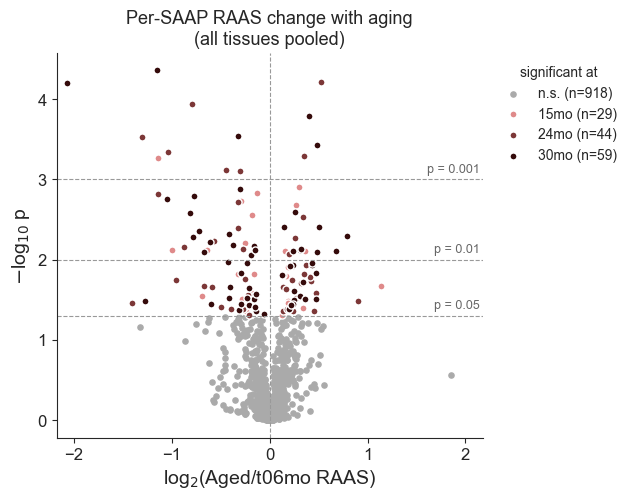


significant SAAP-changes (p <= 0.05) plotted by aged timepoint:
age
t15mo    29
t24mo    44
t30mo    59


In [55]:
# Volcano of per-SAAP RAAS changes with aging -- ALL aged timepoints + tissues pooled into one plot.
#      x = mean log2(Aged/Young RAAS) (cur.mean - base.mean, scaled to log2); y = -log10 of the active
#      significance metric (FDR or raw p, per the USE_FDR toggle, via sig_col()/sig_label()).
#      Non-significant SAAPs are grey; significant SAAPs (sig_col() <= sig) are colored by the aged
#      timepoint they were compared against the 6mo baseline at (15mo / 24mo / 30mo). Each (tissue x SAAP
#      x comparison) row in aging_ttest_df (cell above) is one point, so a SAAP can appear up to 3x
#      (once per aged timepoint). Older timepoints are drawn last so they sit on top.

# aging-timepoint palette (warm ramp deepening with age); grey = not significant
AGE_COLORS = {'t15mo': "#df8a8a", 't24mo': "#7c3737", 't30mo': "#350b0b"}
NS_COLOR   = '#aaaaaa'

# horizontal reference lines, drawn at -log10 of each value on the active-metric (sig_col()) axis
# SIG_LINES = [0.05, 0.01, 0.001, 0.0001] # pval
SIG_LINES = [0.05, 0.01, 0.001] # FDR

def plot_aging_volcano(df, *, age_colors=AGE_COLORS, ns_color=NS_COLOR, sig_lines=SIG_LINES):
    metric = sig_col()                                       # 'FDR' or 'p_value' per USE_FDR
    d = df.dropna(subset=['mean_log2FC', metric]).copy()
    d['age'] = d['comparison'].str.split().str[0]            # 't15mo' from 't15mo vs t06mo'
    # -log10 with a floor so a metric value of 0 (numeric underflow) stays finite/on-scale
    floor = d.loc[d[metric] > 0, metric].min()
    d['neglog10'] = -np.log10(d[metric].clip(lower=floor))

    sns.set_style('ticks')
    fig, ax = plt.subplots(figsize=(5.5, 5))

    # non-significant background first (significance set earlier in 3c: sig_col() <= sig)
    ns = d[~d['significant']]
    ax.scatter(ns['mean_log2FC'], ns['neglog10'], s=14, color=ns_color, alpha=1,
               linewidths=1, label=f'n.s. (n={len(ns):,})', rasterized=True)
    # significant SAAPs only, colored by aged timepoint, oldest plotted last (on top)
    for age in [a for a in age_order if a in age_colors]:
        sub = d[d['significant'] & (d['age'] == age)]
        ax.scatter(sub['mean_log2FC'], sub['neglog10'], s=26, color=age_colors[age], alpha=1,
                   linewidths=1, edgecolors='white', label=f'{age[1:]} (n={len(sub):,})')

    xlim = np.nanmax(np.abs(d['mean_log2FC'])) * 1.05         # symmetric x so up/down read evenly
    ax.set_xlim(-xlim, xlim)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')

    # horizontal reference lines at the active metric (FDR or p), labeled at the right edge
    for v in sig_lines:
        y = -np.log10(v)
        ax.axhline(y, color='#999999', lw=0.8, ls='--')
        ax.annotate(f'{sig_label()} = {v:g}', (ax.get_xlim()[1], y),
                    xytext=(-2, 3), textcoords='offset points', ha='right', va='bottom',
                    fontsize=9, color='#666666')

    ax.set_xlabel('log$_2$(Aged/t06mo RAAS)', fontsize=14)
    ax.set_ylabel(f'$-$log$_{{10}}$ {sig_label()}', fontsize=14)
    ax.set_title(f'Per-SAAP RAAS change with aging\n(all tissues pooled)', fontsize=13)
    ax.tick_params('both', labelsize=12)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(title='significant at', fontsize=10, title_fontsize=10, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1))

    plt.savefig(PLOT_DIR + 'Aging_RAAS_global_volcano.pdf', bbox_inches='tight')
    plt.savefig(PLOT_DIR + 'Aging_RAAS_global_volcano.png', dpi=600, bbox_inches='tight')
    plt.show()
    return d

_volcano = plot_aging_volcano(aging_ttest_global_df)
print(f"\nsignificant SAAP-changes ({sig_label()} <= {sig}) plotted by aged timepoint:")
print(_volcano[_volcano['significant']].groupby('age').size().reindex(aged).fillna(0).astype(int).to_string())

In [56]:
# Save as Supplemental_Data_3.1.SAAP_age_related.xlsx  (+ ..._statistics.xlsx)
# A subset of SAAP shown confidently to change across aging and their statistics.
# Built from aging_ttest_df (cell "3c"): "confident changers" = SAAPs significant in >=1 aged-vs-6mo
# comparison by the active metric (sig_col() = FDR if USE_FDR else p_value, threshold = sig).

SAAP_INDEX = [*SAAP_KEYS]

# confident changers: any aged timepoint significant vs the 6mo baseline
confident_keys = (aging_ttest_global_df.loc[aging_ttest_global_df[sig_col()] <= sig, SAAP_INDEX]
                  .drop_duplicates())

# statistics table -- every aged-vs-6mo comparison for those confident SAAPs (full stats)
age_related_statistics = (aging_ttest_global_df.merge(confident_keys, on=SAAP_INDEX)
                          .sort_values(SAAP_INDEX + ['comparison'])
                          .set_index(SAAP_INDEX))

age_related_statistics.to_excel(SUPP_DIR + 'Supplemental_Data_4.2.SAAP_global_age_related_statistics.xlsx',
                                sheet_name='statistics', index=True)

# (2) SAAP-level subset -- every SAAP_quant_df row for the confident SAAPs, keeping all
# quant columns, with per-timepoint log2FC + significance appended
_fc_wide = (age_related_statistics.reset_index()
            .pivot_table(index=SAAP_INDEX, columns='comparison', values='mean_log2FC'))
_fc_wide.columns = [f'log2FC {c}' for c in _fc_wide.columns]
_sig_wide = (age_related_statistics.reset_index()
             .pivot_table(index=SAAP_INDEX, columns='comparison', values=sig_col()))
_sig_wide.columns = [f'{sig_label()} {c}' for c in _sig_wide.columns]
_stats_block = _fc_wide.join(_sig_wide).reset_index()

age_related_saaps = (SAAP_quant_df.reset_index()
                     .merge(confident_keys, on=SAAP_INDEX, how='inner')
                     .merge(_stats_block, on=SAAP_INDEX, how='left')
                     .sort_values(SAAP_INDEX + ['Sample Type', 'Replicate']))

age_related_saaps.to_excel(SUPP_DIR + 'Supplemental_Data_4.1.SAAP_global_age_related.xlsx',
                           sheet_name='SAAP_age_related', index=False)



# age_gene_list = pd.DataFrame({
#     'MTP_seq': age_related_saaps['MTP_seq'],
#     'BP_seq': age_related_saaps['BP_seq'],
#     'swap': age_related_saaps['aa_sub'],
#     'gene': age_related_saaps['Source_gene'],
#     'accession': age_related_saaps['Source_accessions'],
#     'protein': age_related_saaps['Source_protein']
# }).drop_duplicates()

# print(age_gene_list)

# age_gene_list.to_csv(SUPP_DIR + 'Data_5.SAAP_global_age_related_gene_list.tsv',sep='\t',index=False)


age_gene_list = pd.DataFrame({
    'MTP_seq': age_related_saaps['MTP_seq'],
    'BP_seq': age_related_saaps['BP_seq'],
    'swap': age_related_saaps['aa_sub'],
    'gene': age_related_saaps['Source_gene'],
    'accession': age_related_saaps['Source_accessions'],
    'protein': age_related_saaps['Source_protein']
}).drop_duplicates()

print(age_gene_list)

age_gene_list.to_csv(SUPP_DIR + 'Data_5.SAAP_global_age_related_gene_list_leading_only.tsv',sep='\t',index=False)

                  MTP_seq               BP_seq    swap     gene accession  \
299              AAQEEYVK             AAQEEYIK  I to V    Aldoa    P05064   
779     AGPDTPEAAVEHPEAVR    AGPWTPEAAVEHPEAVR  W to D     Bhmt    O35490   
603   AIAELGIDPAVDPLDSTSR  AIAELGIYPAVDPLDSTSR  Y to D  Atp5f1b    P56480   
1087       APEVDVQGPEDSLK       APEVDVQGPEWSLK  W to D    Ahnak    E9Q616   
1151         ASDTSITNNNLK         ASDTSITWNNLK  W to N       Tf    Q921I1   
...                   ...                  ...     ...      ...       ...   
760     VMLGTTNPADSKPGTIR    VMLGETNPADSKPGTIR  E to T     Nme2    Q01768   
1449         VNAYNLSDNPYK         VNAYNLSDNVYK  V to P      Neb    E9Q1W3   
943       VNSVNPGVVLTDMGK      VNSVNPTVVLTDMGK  T to G     Cbr2    P08074   
664              VQLTDAEK             VHLTDAEK  H to Q   Hbb-bs    A8DUK4   
811           YVMGDAPDFDR          YTMGDAPDFDR  T to V    Gstm1    P10649   

                                                protein  
299              

# Spearmann Correlations of RAAS with Aging

# Relative RAAS computed for shared SAAP between 2 mouse samples

In [57]:
# Create a matrix with median  of relative RAAS computed for shared peptides between each pair of patients. Or read in below

all_ds_matrices = {}
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))
ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)

for sample1 in set_samples:
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]

    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        row_shared_raas_ratios = []
        col_shared_raas_ratios = []
        
        # for each SAAP shared between 2 patients, compute relative RAAS on log2 scale
        for sb, saap_bp in enumerate(shared_saap_bp):
            saap = saap_bp.split(':')[0]
            bp = saap_bp.split(':')[1]
            raas1 = sample1_df.loc[(sample1_df['MTP_seq']==saap) & (sample1_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            raas2 = sample2_df.loc[(sample2_df['MTP_seq']==saap) & (sample2_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            if ~np.isnan(raas1) and ~np.isnan(raas2) and ~np.isinf(raas1) and ~np.isinf(raas2):
                raas_ratio = raas1 - raas2
                raas_ratio = np.log2(10**raas_ratio)
                col_raas_ratio = raas2 - raas1
                col_raas_ratio = np.log2(10**col_raas_ratio)
                row_shared_raas_ratios.append(raas_ratio)
                col_shared_raas_ratios.append(col_raas_ratio)
        ds_matrix_rowcol.loc[sample1, sample2] = np.nanmedian(row_shared_raas_ratios)
        ds_matrix_rowcol.loc[sample2, sample1] = np.nanmedian(col_shared_raas_ratios)

all_ds_matrices['All_data'] = {'Row_col':ds_matrix_rowcol}

# Add N SAAP per comparison to all_data matrix
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))

ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)
for i,sample1 in enumerate(set_samples):
    if i%100==0:
        print(i)
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]
    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        ds_matrix_rowcol.loc[sample1, sample2] = len(shared_saap_bp)
        ds_matrix_rowcol.loc[sample2, sample1] = len(shared_saap_bp)

all_ds_matrices['All_data']['N_shared_saap'] = ds_matrix_rowcol

pickle.dump(all_ds_matrices, open(OUTDIR+'All_pairwise_sample_RAAS_ratio_matrices_log2.p', 'wb'))

0
100


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_65344/1402651026.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)


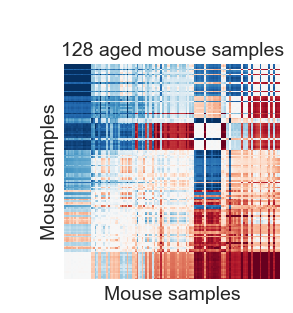

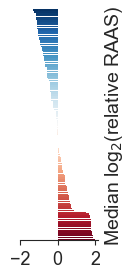

In [58]:
# plot heatmap sorted by row/col median 
ds = 'All_data'

ds_matrix = all_ds_matrices[ds]['Row_col'].astype(float)
medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in ds_matrix.iterrows()]
srt_idx = np.argsort(medians)
col_medians = [np.median([x for x in ds_matrix[col].to_list() if ~np.isnan(x)]) for col in ds_matrix.columns]
col_srt_idx = np.argsort(col_medians)
plot_matrix = ds_matrix.iloc[srt_idx, col_srt_idx]


c = sns.clustermap(plot_matrix, row_cluster=False, col_cluster=False, cmap='RdBu_r', center=0, robust=True, 
                   yticklabels=False, xticklabels=False, figsize=(3,3))#, cbar_kws={'ticklocation':'left'})
c.ax_cbar.set_visible(False)
c.ax_heatmap.set_xlabel('Mouse samples', fontsize=14)
c.ax_heatmap.set_ylabel('Mouse samples', fontsize=14)
c.ax_heatmap.yaxis.set_label_position('left')
c.ax_heatmap.set_title('128 aged mouse samples', fontsize=14)

c.savefig(OUTDIR+ds+'_Paired_RAAS_ratios_btwn_samples_median_sorted_rowcol_log2_nocbar.pdf', bbox_inches='tight')

medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in plot_matrix.iterrows()]

# barplot of patient medians
srt_medians = [medians[i] for i in srt_idx]
str_srt_idx = [str(x) for x in srt_idx]
plot_df = pd.DataFrame(zip(str_srt_idx, srt_medians), columns=['Index','Median log$_{10}$(RAAS) ratio'])
plot_df.sort_values('Median log$_{10}$(RAAS) ratio', inplace=True)

sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(1,3))
sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)
ax.set_ylabel(None)
ax.set_yticks([]);
ax.tick_params('x', labelsize=13)
plt.ylabel('Median log$_{2}$(relative RAAS)', fontsize=14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([-2,0,2]);
ax.yaxis.set_label_position('right')

plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.png',dpi=600, bbox_inches='tight')

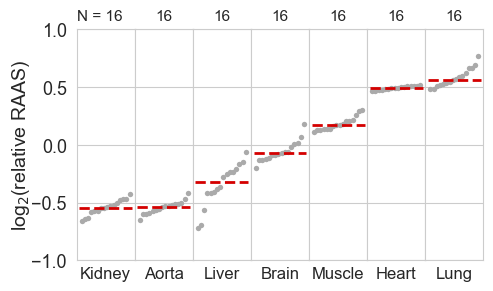

In [59]:
# Weighted means of relative RAAS for each patient in each dataset

def weighted_mean(vals, ns):
    """mean weighted by the number of shared SAAP"""
    m = (~np.isnan(vals)) & (~np.isnan(ns)) & (ns > 0)
    if np.sum(m) == 0:
        return np.nan
    return np.sum(vals[m]*ns[m]) / np.sum(ns[m])

all_ds_matrices = pickle.load(open(OUTDIR+'All_Pairwise_sample_RAAS_ratio_matrices_log2.p', 'rb'))

# matrices are nested under 'All_data' (top-level key), not at the root
block = all_ds_matrices['All_data']
all_ds_matrix   = block['Row_col'].astype(float)
all_ds_n_matrix = block['N_shared_saap'].astype(float)

# unit_dataset maps each sample ID -> tissue. It isn't stored in the pickle, so derive it
# from the index labels: '<tissue>_rep<k>_t<age>mo' -> tissue is the token before the first '_'.
unit_dataset = pd.Series(
    {s: s.split('_')[0].capitalize() for s in all_ds_matrix.index},
    name='unit_dataset')

plot_datasets = datasets[:-1]
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, len(plot_datasets), figsize=(0.75*len(plot_datasets), 3), sharey=True)
plt.subplots_adjust(wspace=0)

# get medians for sorting datasets in plot
medians = []
for i, ds in enumerate(datasets[:-1]):
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix  = all_ds_n_matrix.loc[ds_samples]
    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r, row in n_matrix.iterrows()]
    vals = [x for x in weighted_means if ~np.isnan(x)]
    medians.append(np.median(vals))
srt_idx = np.argsort(medians)
ds_sorted = [datasets[:-1][i] for i in srt_idx]

# plot weighted means
for i, ds in enumerate(ds_sorted):
    ax = axes[i]
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix  = all_ds_n_matrix.loc[ds_samples]

    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r, row in n_matrix.iterrows()]
    vals = weighted_means
    srt_idx = np.argsort(vals)
    srt_vals = [vals[s] for s in srt_idx]
    plot_df = pd.DataFrame(zip(list(range(len(vals))), srt_vals), columns=['Rank', 'RAAS ratio'])

    sns.scatterplot(data=plot_df, y='RAAS ratio', x='Rank', ax=ax, linewidth=0, s=15, color='#aaaaaa')
    ax.set_xlabel(ds, fontsize=12)
    ax.set_xticks([])
    n = len(srt_vals)
    if i == 0:
        ax.annotate('N = '+str(int(np.round(n, 0))), xy=(0.8, 1.04), xycoords='axes fraction', ha='right', fontsize=11)
    else:
        ax.annotate(str(int(np.round(n, 0))), xy=(0.5, 1.04), xycoords='axes fraction', ha='center', fontsize=11)
    median = np.median([x for x in vals if ~np.isnan(x)])
    ax.plot(ax.get_xlim(), (median, median), color='#d40000', linestyle='--', linewidth=2)

axes[0].set_yticks([-1, -0.5, 0, 0.5, 1])
axes[0].tick_params('y', labelsize=13)
axes[0].set_ylabel('log$_{2}$(relative RAAS)', fontsize=14, labelpad=-0.5)

plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.png', dpi=600, bbox_inches='tight')